<a href="https://colab.research.google.com/github/DanielPeled7/ML-Project-2-Stock-Market/blob/main/Kairognos_ML_Full_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting 10% Stock Gains within 30 Days — Full ML Workflow

**Project:** Predict whether a stock snapshot will gain >=10% within the next 30 trading days.  
**Type:** Binary classification on tabular technical-indicator features.  
**Author:** Mr. Daniel  

| #  | Stage | Section |
|----|---|---------|
| 1  | Setup & Imports | §1      |
| 2  | Data Overview | §2      |
| 3  | Numeric Feature Correlations | §3      |
| 4  | Statistical Analysis | §4      |
| 5  | Feature Selection & Preprocessing | §5      |
| 6  | Define Objective | §6      |
| 7  | Time-Based Split + Embargo | §7      |
| 8  | Preprocessing for Modelling | §8      |
| 9  | Evaluation Helpers | §9      |
| 10 | Baseline — Logistic Regression | §10     |
| 11 | Imbalance Handling | §11     |
| 12 | Stronger Models & Model Comparison | §12     |
| 13 | Feature Engineering | §13     |
| 14 | Hyperparameter Tuning | §14     |
| 15 | Cascade Pipeline | §15     |
| 16 | Stacking Pipeline | §16     |
| 17 | Final Test-Set Evaluation | §17     |
| 18 | Interpretability | §18     |
| 19 | Operating-Point Analysis | §19     |
| 20 | Summary & Limitations | §20     |


## §1. Setup & Imports

All libraries for both EDA and modelling are imported here. Adjust `DATA_PATH` if your parquet file is in a different location.

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

# Core data science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

# Sklearn — preprocessing, selection, metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold, TimeSeriesSplit
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
)

# Optional boosting libraries
try:
    import lightgbm as lgb
except ImportError:
    lgb = None
try:
    import xgboost as xgb
except ImportError:
    xgb = None

# Optional imbalance handling
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
except ImportError:
    SMOTE = None

# Optional SHAP
try:
    import shap
except ImportError:
    shap = None

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')

print('Setup OK')
print(f'  LightGBM : {"available" if lgb   else "not installed"}')
print(f'  XGBoost  : {"available" if xgb   else "not installed"}')
print(f'  SMOTE    : {"available" if SMOTE else "not installed"}')
print(f'  SHAP     : {"available" if shap  else "not installed"}')


Setup OK
  LightGBM : available
  XGBoost  : available
  SMOTE    : available
  SHAP     : available


In [ ]:
# Configure pandas display settings for better readability
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 1000)         # Prevent line wrapping
pd.set_option('display.max_colwidth', None)  # Show full text in columns

In [ ]:
# Set visualization style and default figure size
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## §2. Data Overview

Load Dataset: Loads the dataset from a Parquet file and displays a preview.

In [ ]:
import os
import pandas as pd
from getpass import getpass # Import getpass for interactive password input

# Install gdown and py7zr if not already installed
print("Installing gdown and py7zr...")
!pip install gdown py7zr --quiet
import gdown
import py7zr

# Define file_id explicitly
file_id = '1dhGpsUs523SYgxeZnxkHAmicF_HE3jHJ' # Updated from user input

# Prompt the user for the password
print("\n--- Enter Password for .7z Archive ---")
password = getpass("Please enter the password for the .7z file: ")

# Define the local path where the .7z file will be downloaded
sevenz_output_file = "c:/Users/jzore/PycharmProjects/StocksML/content/kairognos_cleaned.7z"

# Define the path where the .parquet file will be extracted locally in Colab
# Ensure this matches the name of the .parquet file INSIDE the .7z archive.
parquet_output_file = 'c:/Users/jzore/PycharmProjects/StocksML/content/kairognos_cleaned.parquet'

df = pd.DataFrame() # Initialize df to empty DataFrame in case of errors

print(f"Downloading file with ID '{file_id}' to '{sevenz_output_file}'...")
gdown.download(id=file_id, output=sevenz_output_file, quiet=True)

if os.path.exists(sevenz_output_file):
    print(f"Successfully downloaded '{sevenz_output_file}'. Now extracting...")
    try:
        # py7zr.SevenZipFile takes the password directly as a string
        with py7zr.SevenZipFile(sevenz_output_file, mode='r', password=password) as archive:
            archive.extractall(path=os.path.dirname(parquet_output_file))
        print(f"Successfully extracted '{sevenz_output_file}' to '{os.path.dirname(parquet_output_file)}'.")

        # Load the .parquet file
        if os.path.exists(parquet_output_file):
            df = pd.read_parquet(parquet_output_file)
            print(f"Successfully loaded {parquet_output_file} into a DataFrame with {len(df)} rows and {len(df.columns)} columns.")
            display(df.sort_values(by='timestamp', ascending=True).head())
        else:
            print(f"Error: Parquet file '{parquet_output_file}' not found after extraction.\nEnsure the .parquet file inside the .7z has this exact name and is extracted to the correct location.")
    except py7zr.Bad7zFile:
        print("Error extracting file: The file is not a valid .7z archive or is corrupted.")
        print("Please check the integrity of your .7z file.")
    except Exception as e:
        # py7zr raises an OSError for incorrect password (among others)
        if "wrong password" in str(e).lower(): # Check if error message indicates wrong password
            print(f"Error extracting file: Wrong password. Please check the password: {e}")
        else:
            print(f"An unexpected error occurred during extraction: {e}")
else:
    print(f"Error: Failed to download file with ID '{file_id}'. Please check the ID and access permissions.")

print(f'Shape: {df.shape}')
print(f'Date range: {df["timestamp"].min().date()} to {df["timestamp"].max().date()}')
print(f'Unique symbols: {df["symbol"].nunique()}')
df.head()


Installing gdown and py7zr...



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



--- Enter Password for .7z Archive ---
Successfully downloaded 'c:/Users/jzore/PycharmProjects/StocksML/content/kairognos_cleaned.7z'. Now extracting...
Successfully extracted 'c:/Users/jzore/PycharmProjects/StocksML/content/kairognos_cleaned.7z' to 'c:/Users/jzore/PycharmProjects/StocksML/content'.
Successfully loaded c:/Users/jzore/PycharmProjects/StocksML/content/kairognos_cleaned.parquet into a DataFrame with 577400 rows and 88 columns.


,symbol,exchange,timestamp,close,volume,ma_200,rsi_14,macd,macd_histogram,stoch_k,adx,atr_5,atr_10,adr,bb_width_pct,avg_volume_30d,volume_ratio,vcp_t_count,consolidation_days,consolidation_range_pct,relative_strength,plus_di,minus_di,cci_20,obv,vcs_score,higher_highs,higher_lows,lower_highs,ath_distance_pct,pa_quality_score,pa_quality_label,weekly_trend_status,is_consolidating,ma_slope,rsi_pullback,distribution_detected,breakout_detected,breakout_days_since,breakout_is_strong,sector_rs,adr_past,vcp_t1_depth,vcp_t2_depth,breakout_is_weak,breakout_is_suspicious,distribution_days,strong_uptrend,market_regime,spy_distance_from_200,sector_leading,stock_leading_sector,adr_declining,vcp_is_valid,ma_alignment,above_fast_ma,above_long_ma,vcp_state,slope_category,weekly_trend_partial_week,price_vs_ma_200_pct,history_bars,volume_surge_label,rs_state,vcs_label,macd_state,stoch_state,adx_state,cci_state,obv_state,days_since_ath,volume_days_above_avg_10,pa_body_score,pa_momentum_score,pa_close_score,pa_volume_score,rsi_pullback_label,is_biotech,signal_type,warning_count,warning_extended_move,warning_gap_down,warning_failed_breakout,warning_broke_fast_ma,warning_below_fast_ma,warning_below_long_ma,warning_distribution,gain_10pct_30d
0,AGG,NYSE ARCA,2015-01-02 00:00:00+00:00,110.430,2090232.0,79.599000,62.443700,0.133300,0.017800,62.00270,16.780700,0.317500,0.322700,0.234664,0.958022,1943951.07,1.075249,0,3,0.445414,-4.697087,32.397429,21.391781,80.026700,91802491.0,32.8,5,5,2,1.472163,67,Moderate,Building,True,-0.073045,False,False,False,-1,False,0.0,0.205712,0.000000,0.000000,False,False,3.0,False,Bullish,4.841987,False,False,True,False,True,True,True,No Pattern,zero,False,38.732899,2638,normal,underperforming,weak,bullish,neutral,weak_ranging,neutral,rising,54,8,12,25,10,20,normal,False,pre_breakout,0,False,False,False,False,False,False,False,False
295584,PRF,NYSE ARCA,2015-01-02 00:00:00+00:00,18.270,972345.0,13.908300,53.525100,0.092000,0.012200,77.66990,18.371500,0.836100,0.880500,0.679912,6.354668,870291.17,1.117264,1,3,2.014531,-0.394285,21.134862,29.619950,14.605500,82925105.0,34.8,4,3,4,1.626104,66,Moderate,Moderate,True,1.688809,False,True,False,-1,False,0.0,0.542955,5.060345,0.000000,False,False,1.0,False,Bullish,4.841987,False,False,True,False,True,True,True,VCP Forming,weak,False,31.360411,2270,normal,inline,weak,bullish,neutral,weak_ranging,neutral,falling,3,4,18,18,10,20,neutral,False,pre_breakout,1,False,False,False,False,False,False,True,False
121431,EWY,NYSE ARCA,2015-01-02 00:00:00+00:00,54.710,4266337.0,49.407800,41.042700,-0.212200,0.013200,18.55160,16.178100,0.681300,0.677500,0.744836,4.723680,2779669.97,1.534836,1,0,2.165351,-12.497890,26.283192,41.954431,-111.346500,-74402892.0,37.4,2,2,5,19.259150,48,Weak,Conflicting,True,-0.993582,False,False,False,-1,False,0.0,0.602591,5.799531,0.000000,False,False,6.0,False,Bullish,4.841987,False,False,True,False,False,True,True,VCP Forming,zero,False,10.731504,3481,normal,underperforming,weak,bullish,oversold,weak_ranging,oversold,falling,108,3,10,18,10,10,neutral,False,pre_breakout,0,False,False,False,False,False,False,False,False
194279,IEV,NYSE ARCA,2015-01-02 00:00:00+00:00,42.320,1293141.0,33.722300,38.779200,-0.189300,-0.040900,41.12380,27.305900,0.456900,0.493200,0.779111,7.817116,752814.93,1.717741,3,3,2.024387,-9.524777,16.666747,39.090366,-103.033900,41510381.0,28.0,2,2,6,16.553288,56,Moderate,Conflicting,True,-0.663434,False,True,False,-1,False,0.0,0.541462,5.666364,5.709107,False,False,3.0,False,Bullish,4.841987,False,False,True,False,False,True,True,VCP Forming,zero,False,25.495592,3431,normal,underperforming,weak,bearish,neutral,strong_trend,oversold,falling,136,3,18,18,10,10,normal,False,pre_breakout,1,False,False,False,False,False,False,True,False
456874,TNA,NYSE ARCA,2015-01-02 00:00:00+00:00,39.785,19020026.0,36.170066,54.571056,1.036763,0.183269,78.57175,17.759544,1.624618,1.614705,3.086415,22.151144,13911315.40,1.367234,4,3,9.220668,21.647633,21.871012,23.8185

Shape: (577400, 88)
Date range: 2015-01-02 to 2025-12-31
Unique symbols: 574


,symbol,exchange,timestamp,close,volume,ma_200,rsi_14,macd,macd_histogram,stoch_k,adx,atr_5,atr_10,adr,bb_width_pct,avg_volume_30d,volume_ratio,vcp_t_count,consolidation_days,consolidation_range_pct,relative_strength,plus_di,minus_di,cci_20,obv,vcs_score,higher_highs,higher_lows,lower_highs,ath_distance_pct,pa_quality_score,pa_quality_label,weekly_trend_status,is_consolidating,ma_slope,rsi_pullback,distribution_detected,breakout_detected,breakout_days_since,breakout_is_strong,sector_rs,adr_past,vcp_t1_depth,vcp_t2_depth,breakout_is_weak,breakout_is_suspicious,distribution_days,strong_uptrend,market_regime,spy_distance_from_200,sector_leading,stock_leading_sector,adr_declining,vcp_is_valid,ma_alignment,above_fast_ma,above_long_ma,vcp_state,slope_category,weekly_trend_partial_week,price_vs_ma_200_pct,history_bars,volume_surge_label,rs_state,vcs_label,macd_state,stoch_state,adx_state,cci_state,obv_state,days_since_ath,volume_days_above_avg_10,pa_body_score,pa_momentum_score,pa_close_score,pa_volume_score,rsi_pullback_label,is_biotech,signal_type,warning_count,warning_extended_move,warning_gap_down,warning_failed_breakout,warning_broke_fast_ma,warning_below_fast_ma,warning_below_long_ma,warning_distribution,gain_10pct_30d
0,AGG,NYSE ARCA,2015-01-02 00:00:00+00:00,110.43,2090232.0,79.5990,62.4437,0.1333,0.0178,62.0027,16.7807,0.3175,0.3227,0.234664,0.958022,1943951.07,1.075249,0,3,0.445414,-4.697087,32.397429,21.391781,80.0267,91802491.0,32.8,5,5,2,1.472163,67,Moderate,Building,True,-0.073045,False,False,False,-1,False,0.0,0.205712,0.0,0.0,False,False,3.0,False,Bullish,4.841987,False,False,True,False,True,True,True,No Pattern,zero,False,38.732899,2638,normal,underperforming,weak,bullish,neutral,weak_ranging,neutral,rising,54,8,12,25,10,20,normal,False,pre_breakout,0,False,False,False,False,False,False,False,False
1,AGG,NYSE ARCA,2015-01-05 00:00:00+00:00,110.67,3446236.0,79.6189,65.6422,0.1640,0.0388,75.7444,17.6360,0.3200,0.3235,0.244999,1.043845,2013432.80,1.711622,0,3,0.597628,-1.412964,35.812761,19.816887,145.6605,95248727.0,10.0,5,5,2,1.258030,67,Moderate,Building,True,0.010634,False,False,False,-1,False,0.0,0.209638,0.0,0.0,False,False,3.0,False,Bullish,2.932182,False,False,True,False,True,True,True,No Pattern,weak,True,38.999660,2639,normal,inline,weak,bullish,neutral,weak_ranging,overbought,rising,55,8,12,25,10,20,normal,False,pre_breakout,0,False,False,False,False,False,False,False,False
2,AGG,NYSE ARCA,2015-01-06 00:00:00+00:00,110.95,3688054.0,79.6393,68.9619,0.2026,0.0619,83.9161,19.4635,0.3920,0.3591,0.258801,1.112836,2097841.43,1.758023,0,3,1.061899,-0.381541,42.968017,17.033973,226.4888,98936781.0,0.0,4,4,2,1.008208,65,Moderate,Building,True,0.093925,False,False,False,-1,False,0.0,0.218747,0.0,0.0,False,False,3.0,False,Neutral,1.907044,False,False,True,False,True,True,True,No Pattern,weak,True,39.315639,2640,normal,inline,none,bullish,overbought,weak_ranging,overbought,rising,0,8,10,25,10,20,normal,False,pre_breakout,0,False,False,False,False,False,False,False,False
3,AGG,NYSE ARCA,2015-01-07 00:00:00+00:00,110.93,3984399.0,79.6590,68.4509,0.2293,0.0709,83.2302,20.6217,0.3736,0.3532,0.268458,1.203515,2187488.27,1.821449,0,0,0.787473,-3.672066,40.280471,19.095919,157.7806,94952382.0,0.0,4,4,2,1.026053,37,Weak,Building,True,0.140559,False,False,False,-1,False,0.0,0.246874,0.0,0.0,False,False,3.0,False,Bullish,3.132538,False,False,False,False,True,True,True,No Pattern,weak,True,39.256079,2641,normal,underperforming,none,bullish,overbought,weak_ranging,overbought,rising,1,8,9,18,10,0,normal,False,pre_breakout,1,False,False,True,False,False,False,False,False
4,AGG,NYSE ARCA,2015-01-08 00:00:00+00:00,110.76,2212153.0,79.6786,64.1224,0.2377,0.0634,75.1323,21.3102,0.3589,0.3479,0.243590,1.246874,2216056.00,0.998239,0,1,0.650818,-4.137062,37.738448,20.204775,103.6683,92740229.0,18.4,4,4,2,1.177730,36,Weak,Building,True,0.223025,False,True,False,-1,False,0.0,0.253662,0.0,0.0,False,False,4.0,False,Bullish,4.910245,False,False,T

Basic Dataset Overview: Provides a general understanding of dataset size, structure, missing values, and statistical properties.

In [ ]:
# Display dataset shape (rows, columns)
print("Shape:", df.shape)

# Display data types and non-null counts
print("\nInfo:")
df.info()

# Show top 20 features with most missing values
print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

# Display statistical summary of numerical features
print("\nDescribe:")
display(df.describe().T)

# Display the number of unique values per column
print("\nUnique Values per Column:")
display(df.nunique().sort_values(ascending=False))

Shape: (577400, 88)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 577400 entries, 0 to 577399
Data columns (total 88 columns):
 #   Column                     Non-Null Count   Dtype              
---  ------                     --------------   -----              
 0   symbol                     577400 non-null  str                
 1   exchange                   577400 non-null  str                
 2   timestamp                  577400 non-null  datetime64[us, UTC]
 3   close                      577400 non-null  float64            
 4   volume                     577400 non-null  float64            
 5   ma_200                     577400 non-null  float64            
 6   rsi_14                     577400 non-null  float64            
 7   macd                       577400 non-null  float64            
 8   macd_histogram             577400 non-null  float64            
 9   stoch_k                    577400 non-null  float64            
 10  adx                        577400 non-nu

symbol                     0
exchange                   0
timestamp                  0
close                      0
volume                     0
ma_200                     0
rsi_14                     0
macd                       0
macd_histogram             0
stoch_k                    0
adx                        0
atr_5                      0
atr_10                     0
adr                        0
bb_width_pct               0
avg_volume_30d             0
volume_ratio               0
vcp_t_count                0
consolidation_days         0
consolidation_range_pct    0
dtype: int64


Describe:


,count,mean,std,min,25%,50%,75%,max
close,577400.0,6.047534e+01,6.473741e+01,1.028000e+00,2.546000e+01,3.927000e+01,7.349625e+01,1.400000e+03
volume,577400.0,5.042951e+06,1.055323e+07,0.000000e+00,7.574898e+05,1.701330e+06,4.612811e+06,7.877488e+08
ma_200,577400.0,5.590492e+01,6.650694e+01,9.633600e-01,2.221730e+01,3.471205e+01,6.607428e+01,1.911145e+03
rsi_14,577400.0,5.324226e+01,1.254159e+01,4.701364e+00,4.463232e+01,5.346570e+01,6.173240e+01,1.000000e+02
macd,577400.0,3.255531e-02,2.321713e+00,-1.504057e+02,-1.588000e-01,6.590000e-02,3.580000e-01,1.275056e+02
macd_histogram,577400.0,3.860235e-03,7.120478e-01,-8.758980e+01,-6.760000e-02,1.462687e-03,7.970000e-02,4.347678e+01
stoch_k,577400.0,5.593698e+01,2.954125e+01,-1.296741e-13,2.901383e+01,5.927440e+01,8.382946e+01,1.000000e+02
adx,577400.0,2.269759e+01,9.537249e+00,2.892800e+00,1.592270e+01,2.058470e+01,2.723713e+01,9.440478e+01
atr_5,577400.0,1.152979e+00,3.455299e+00,1.000000e-02,2.928000e-01,5.881000e-01,1.266500e+00,5.567089e+02
atr_10,577400.0,1.153255e+00,3.227162e+00,1.000000e-02,3.012000e-01,5.973000e-01,1.280400e+00,4.222356e+02



Unique Values per Column:


plus_di                  577337
minus_di                 577335
price_vs_ma_200_pct      576910
ma_slope                 576516
avg_volume_30d           568581
                          ...  
warning_broke_fast_ma         2
gain_10pct_30d                2
strong_uptrend                1
signal_type                   1
is_biotech                    1
Length: 88, dtype: int64

Identify Feature Types: Separates numeric and categorical features for appropriate analysis methods.

In [ ]:
# Identify numeric and categorical features
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
bool_cols = df.select_dtypes(include=['bool']).columns

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))
print("Boolean features:", len(bool_cols))

Numeric features: 45
Categorical features: 17
Boolean features: 25


Target Variable Analysis: Analyzes the distribution of the target variable to detect imbalance and understand prediction difficulty.

gain_10pct_30d
False    517450
True      59950
Name: count, dtype: int64
gain_10pct_30d
False    0.896172
True     0.103828
Name: proportion, dtype: float64


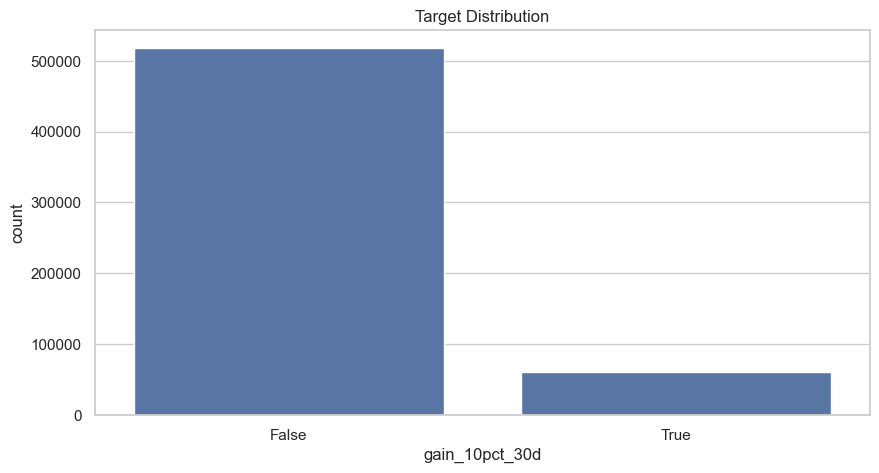

In [ ]:
# Define target variable
target_col = "gain_10pct_30d"

# Show class distribution (counts and proportions)
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True))

# Visualize target distribution
sns.countplot(x=df[target_col])
plt.title("Target Distribution")
plt.show()

Missing Values (Full Check): Checks missing values across all features.

In [ ]:
# Display total missing values per feature
pd.set_option('display.max_rows', None)
print(df.isnull().sum().sort_values(ascending=False))

symbol                       0
exchange                     0
timestamp                    0
close                        0
volume                       0
ma_200                       0
rsi_14                       0
macd                         0
macd_histogram               0
stoch_k                      0
adx                          0
atr_5                        0
atr_10                       0
adr                          0
bb_width_pct                 0
avg_volume_30d               0
volume_ratio                 0
vcp_t_count                  0
consolidation_days           0
consolidation_range_pct      0
relative_strength            0
plus_di                      0
minus_di                     0
cci_20                       0
obv                          0
vcs_score                    0
higher_highs                 0
higher_lows                  0
lower_highs                  0
ath_distance_pct             0
pa_quality_score             0
pa_quality_label             0
weekly_t

Feature Distributions: Visualizes distributions of all numeric features to detect skewness, outliers, and unusual patterns.

In [ ]:
#Pink = Left tail, Green = Right tail, No color = close to normal
df_num=df._get_numeric_data().dropna()

def highlight(cell_value):
    if cell_value > 1:
        return 'background-color: green;'
    elif cell_value < -1:
        return 'background-color: hotpink;'
    return ''

pd.DataFrame(df_num.skew(),columns=['skewness']).sort_values(by='skewness', key=lambda x: x.abs(), ascending=False)

,skewness
atr_5,71.265852
atr_10,61.693421
warning_extended_move,61.407459
vcp_is_valid,42.244833
macd_histogram,-25.380928
macd,-15.286263
warning_gap_down,13.453957
breakout_is_suspicious,11.553224
consolidation_range_pct,10.581214
warning_failed_breakout,9.118811


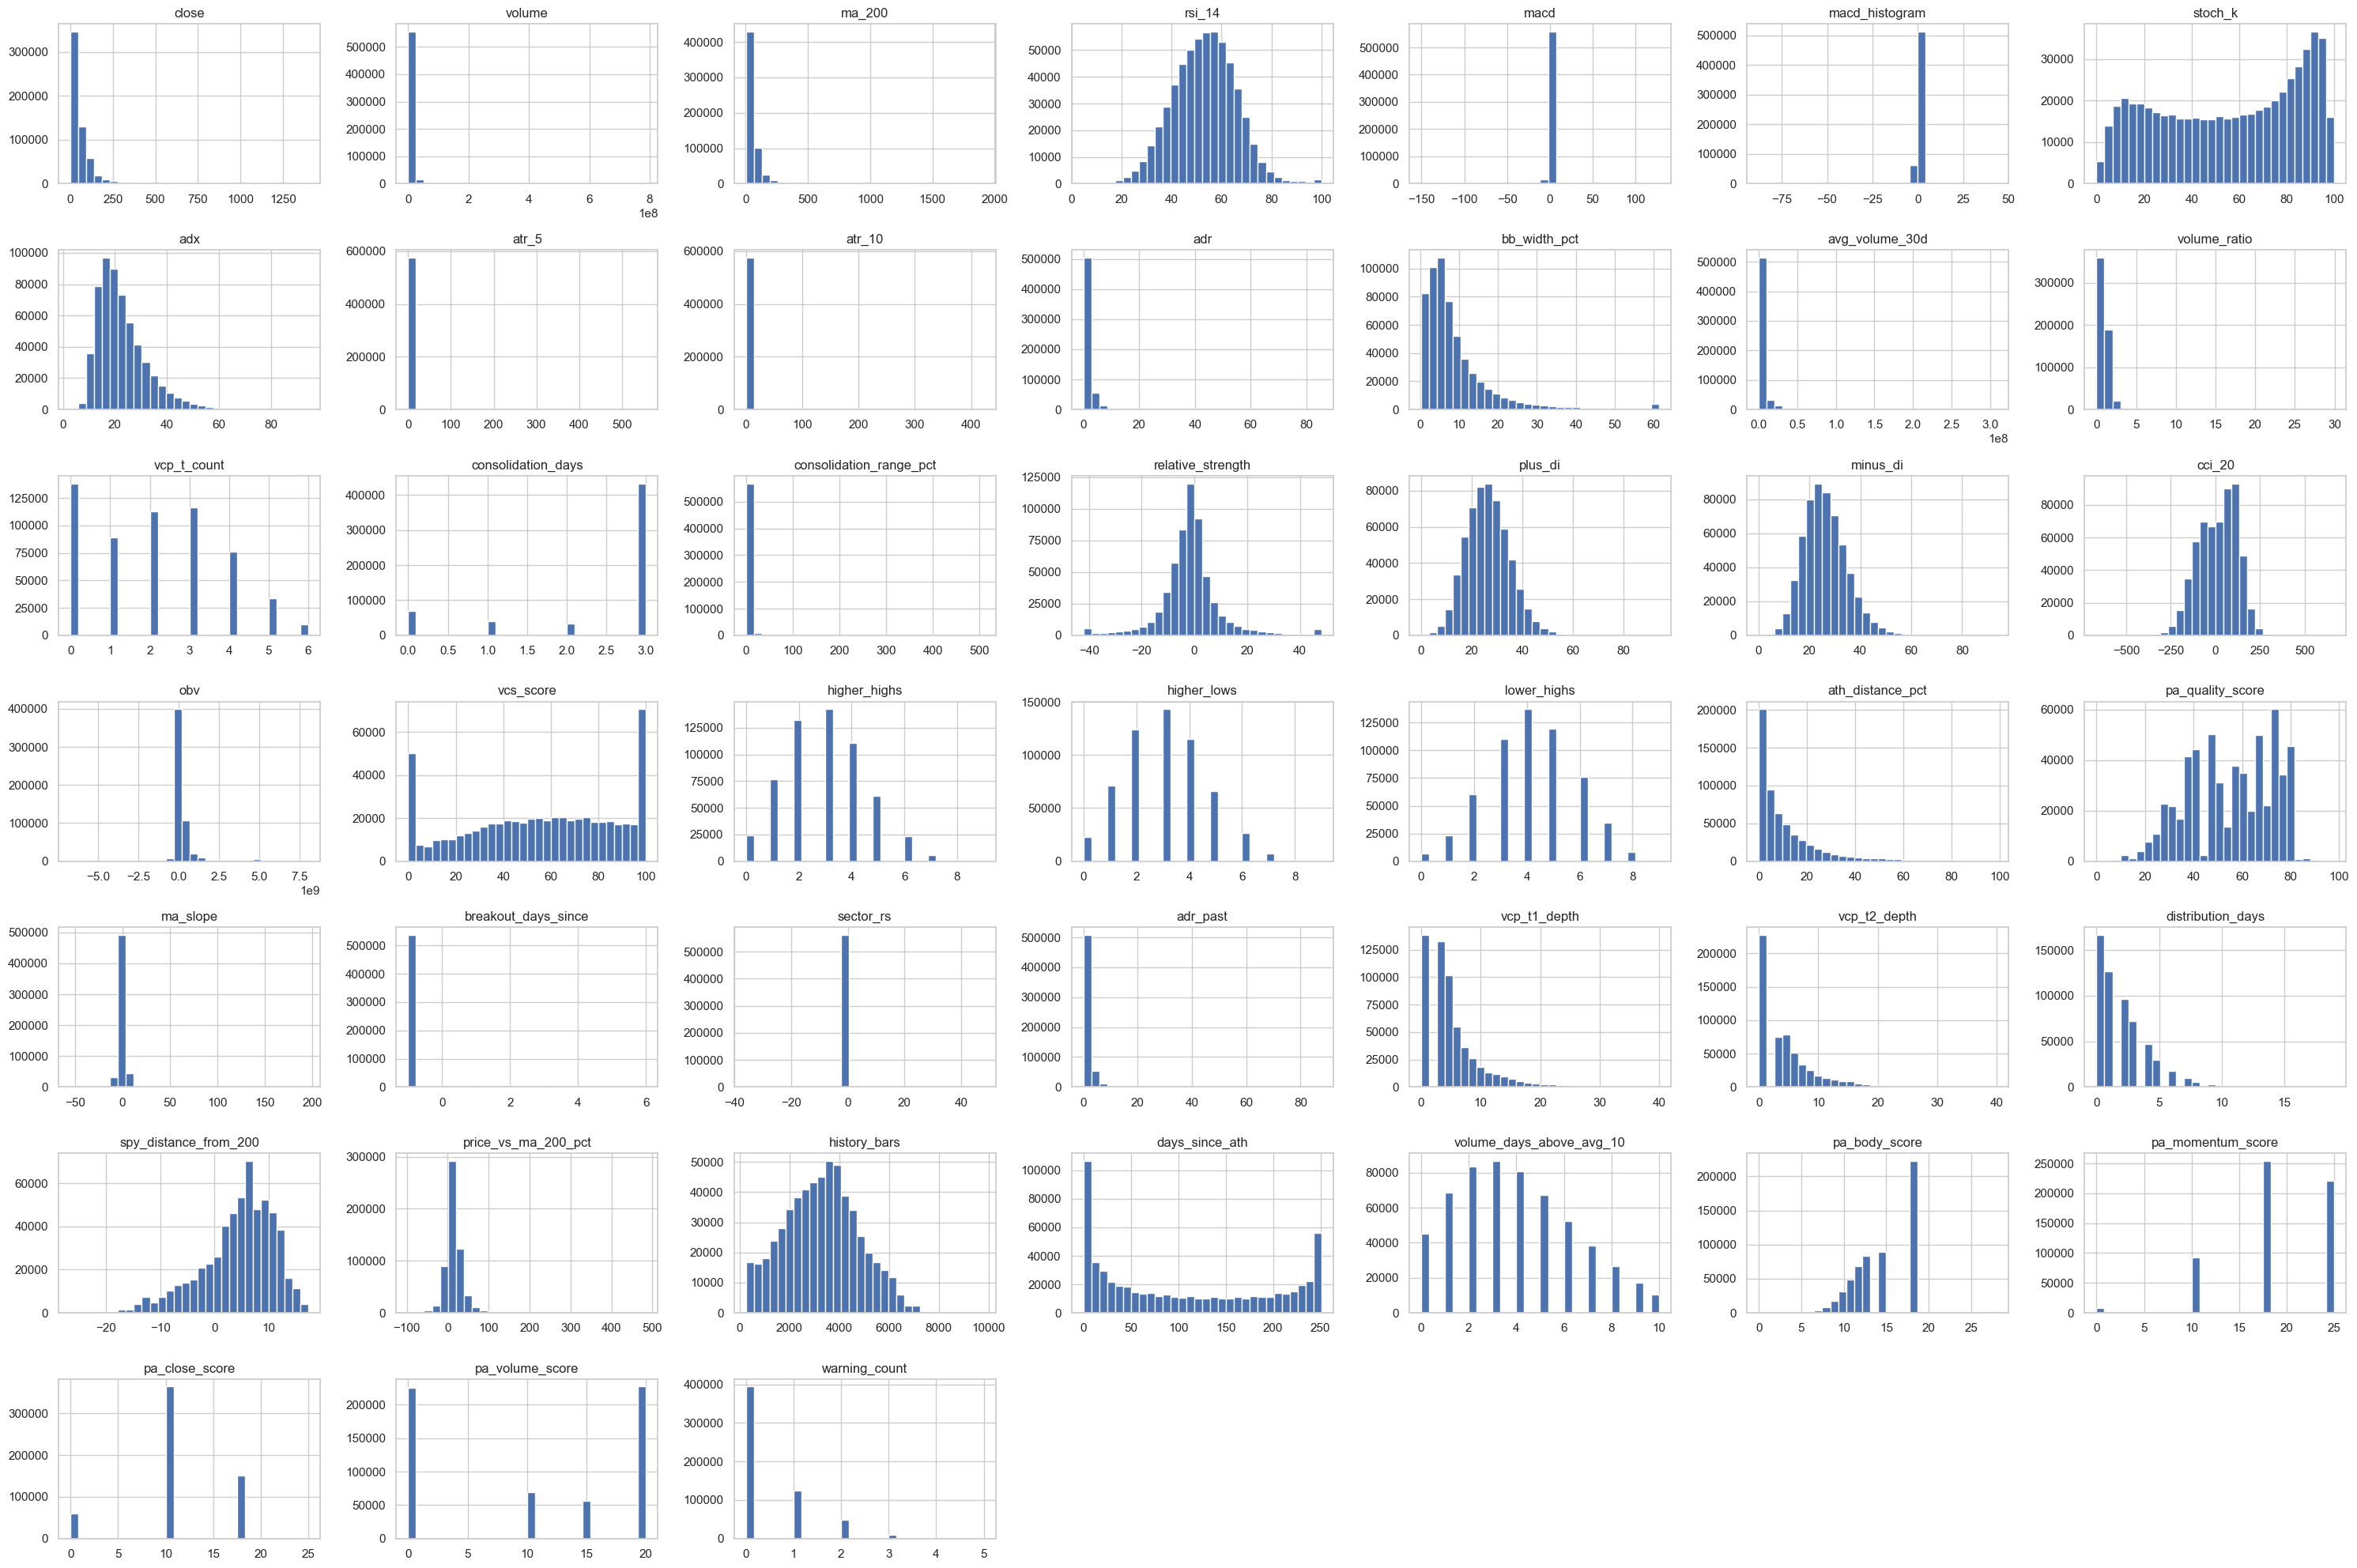

In [ ]:
# Plot histograms for all numeric features
df.select_dtypes(include=['number']).hist(figsize=(30,20), bins=30)
plt.tight_layout()
plt.show()

## §3. Numeric Features Correlation

Correlation Matrix (Spearman): Computes correlation matrix using Pearson correlation, which measures linear relationships between numeric features.

,Feature 1,Feature 2,Pearson,Spearman,Diff,Relationship
324,atr_5,atr_10,0.977826,0.995363,0.017537,Linear
1,close,ma_200,0.948356,0.965263,0.016907,Linear
852,pa_quality_score,pa_volume_score,0.902516,0.906133,0.003618,Linear
54,volume,avg_volume_30d,0.893505,0.904343,0.010838,Linear
262,stoch_k,cci_20,0.880774,0.899350,0.018576,Linear
400,adr,consolidation_range_pct,0.835548,0.894980,0.059431,Linear
850,pa_quality_score,pa_momentum_score,0.883503,0.890396,0.006893,Linear
415,adr,adr_past,0.745286,0.868044,0.122759,Non-linear (Monotonic)
145,rsi_14,cci_20,0.808155,0.865844,0.057689,Linear
395,adr,bb_width_pct,0.846504,0.854120,0.007616,Linear


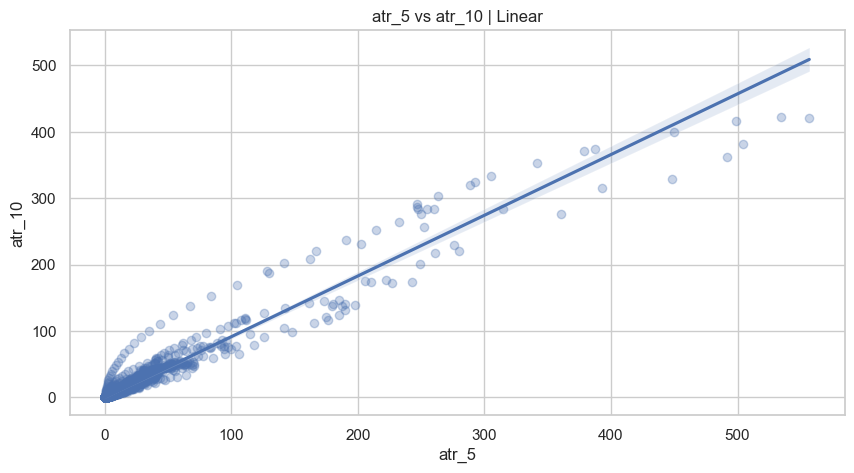

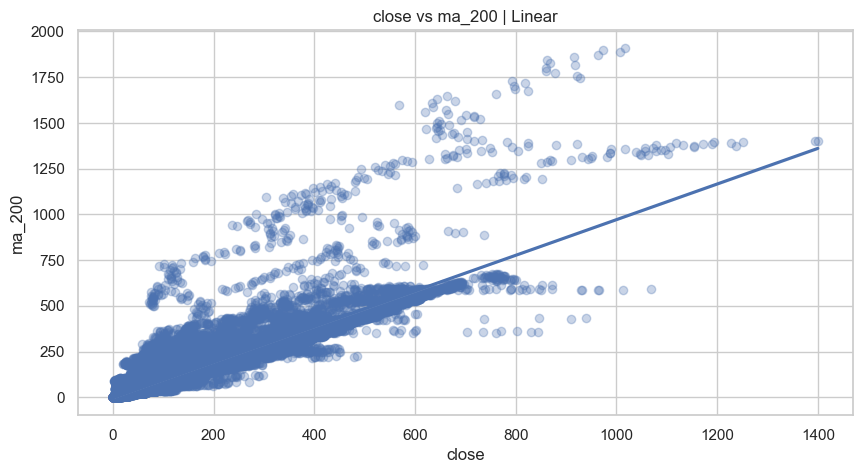

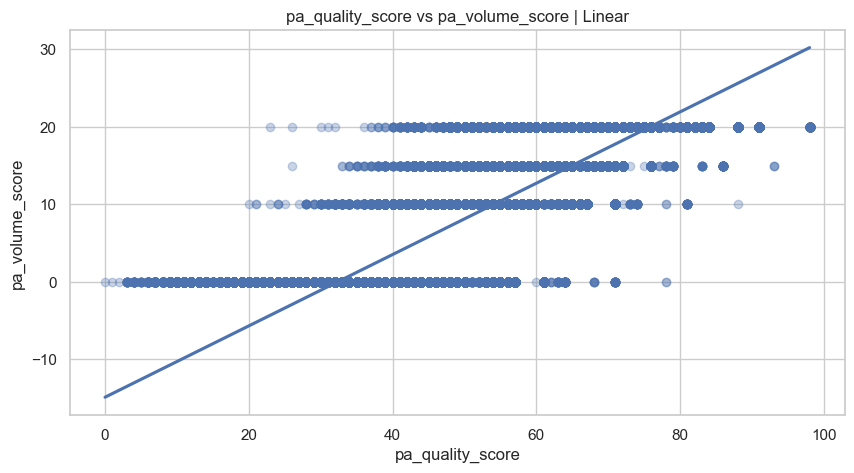

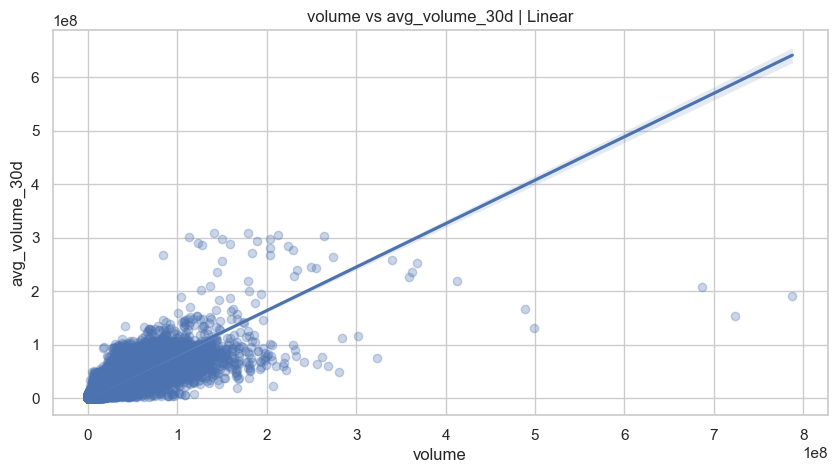

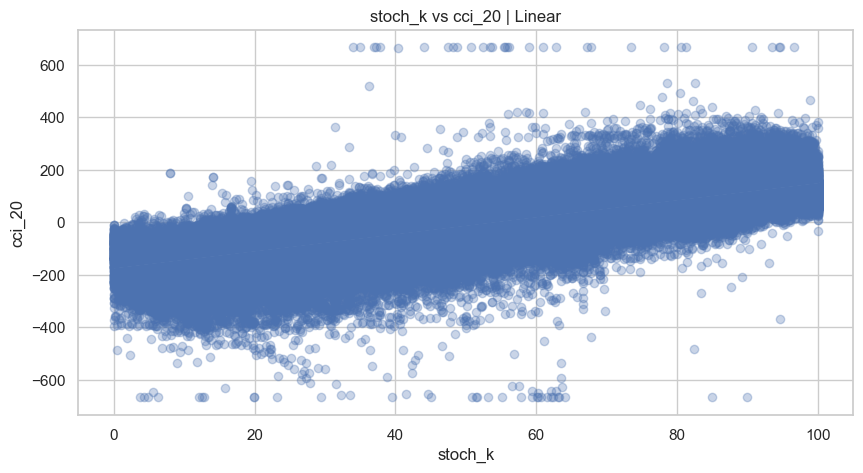

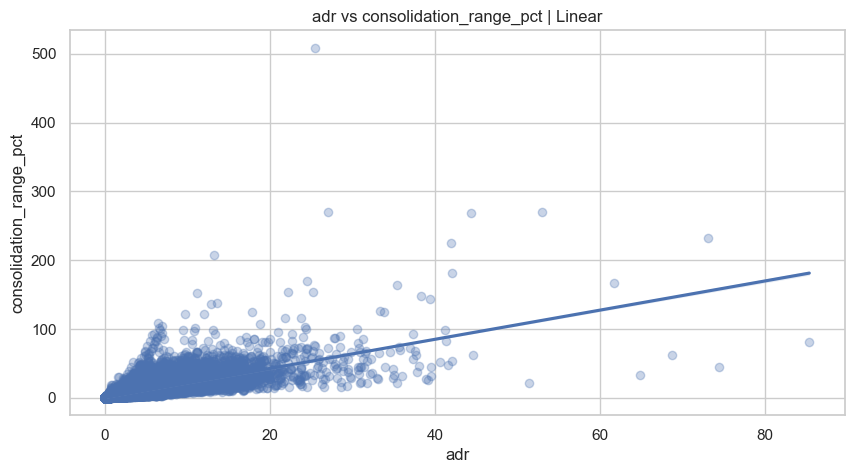

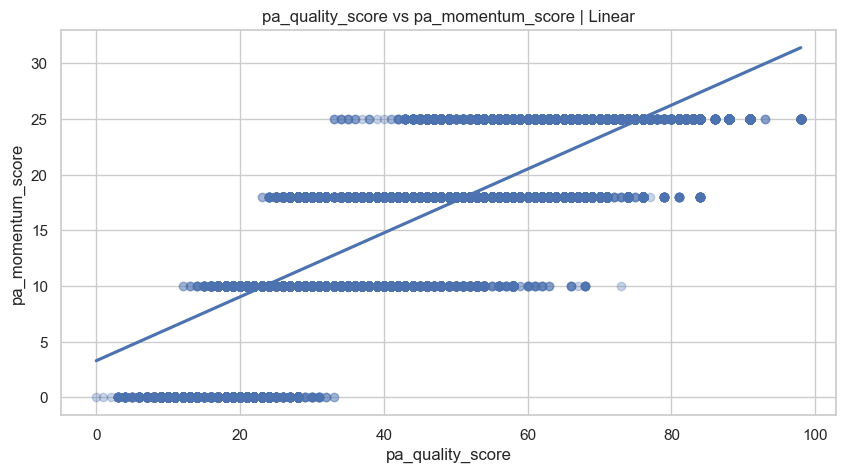

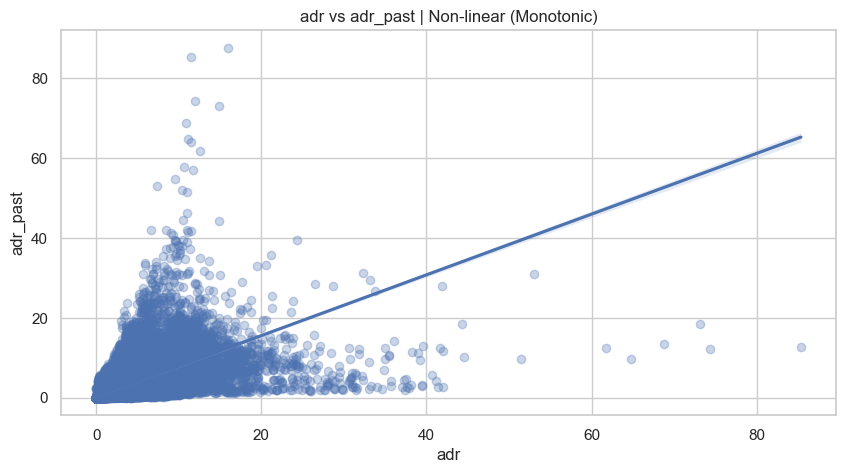

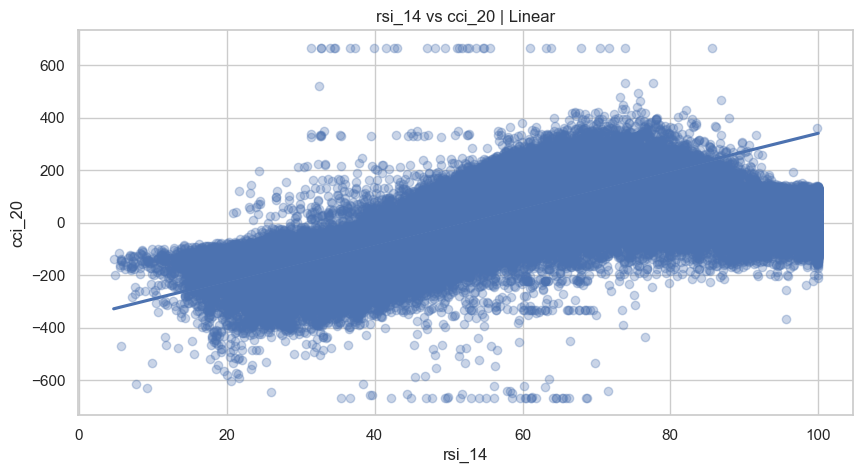

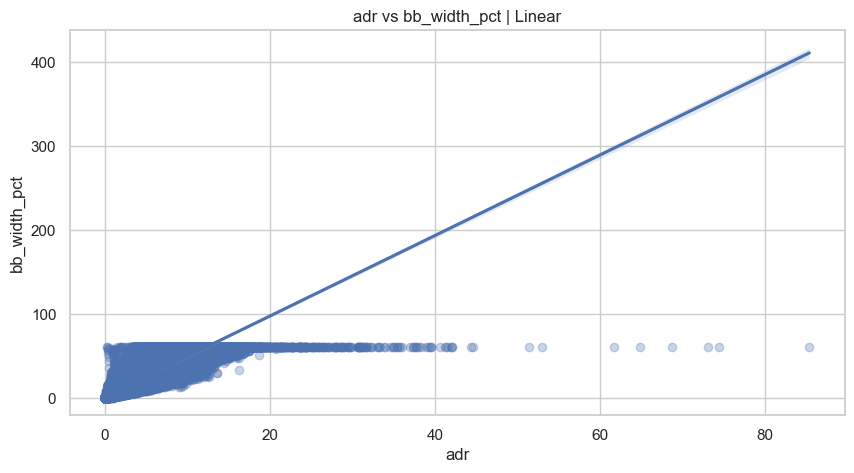

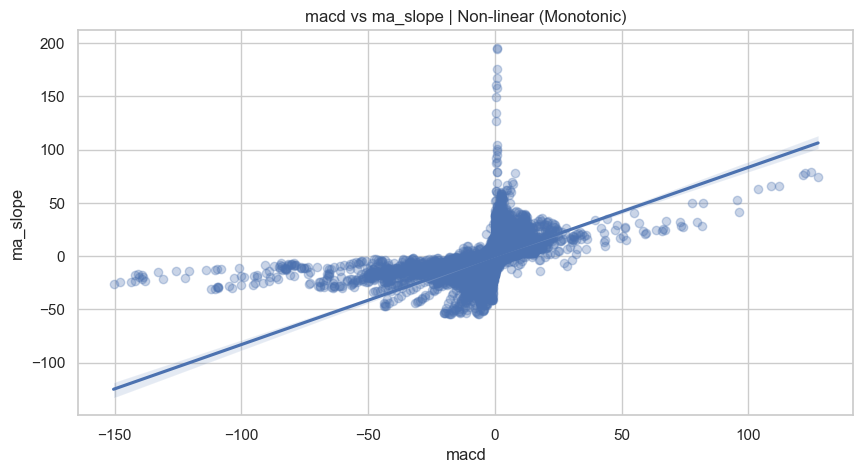

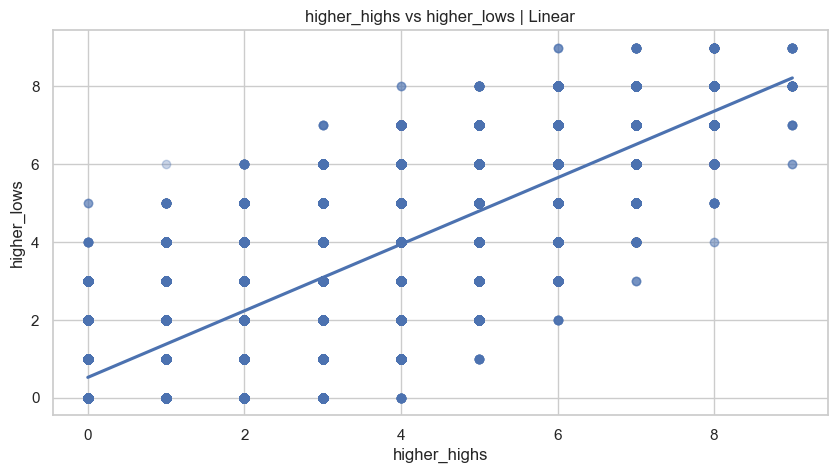

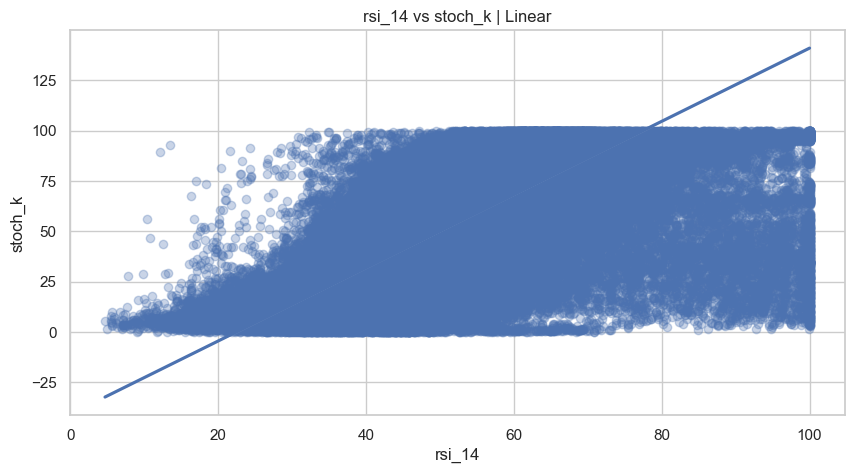

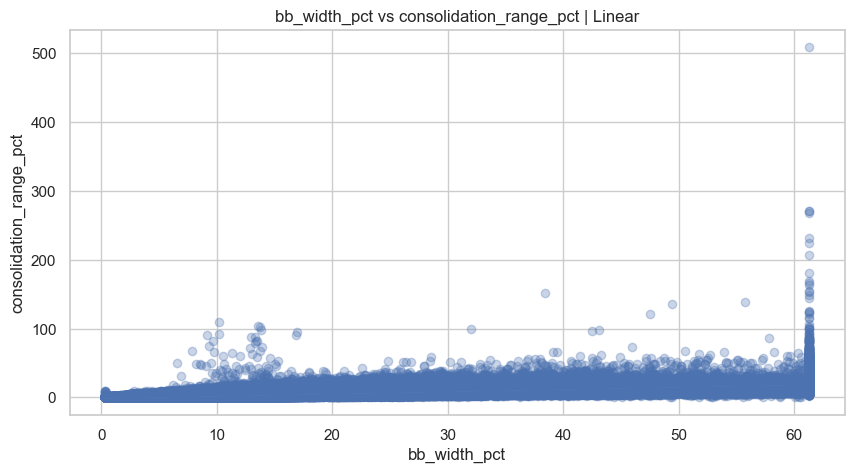

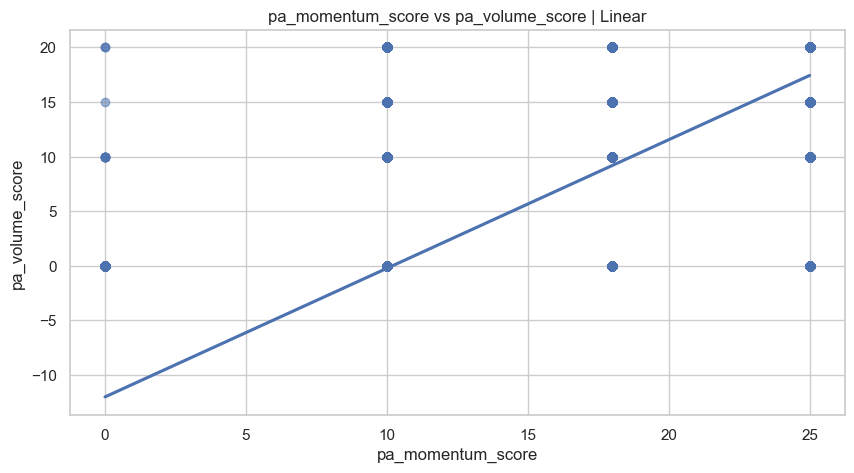

In [ ]:
# =========================================
# 1. Compute Correlations
# =========================================

corr_pearson = df[numeric_cols].corr(method='pearson')
corr_spearman = df[numeric_cols].corr(method='spearman')

# Difference between correlations (detect non-linearity)
diff = (corr_spearman - corr_pearson).abs()


# =========================================
# 2. Create Pairwise Table
# =========================================

pairs = []

for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        f1 = numeric_cols[i]
        f2 = numeric_cols[j]

        p = corr_pearson.loc[f1, f2]
        s = corr_spearman.loc[f1, f2]
        d = abs(s - p)

        # Classification logic
        if abs(p) > 0.7 and d < 0.1:
            relation = "Linear"
        elif abs(s) > 0.7 and d >= 0.1:
            relation = "Non-linear (Monotonic)"
        elif abs(s) > 0.5:
            relation = "Weak/Moderate"
        else:
            relation = "No strong relationship"

        pairs.append([f1, f2, p, s, d, relation])


rel_df = pd.DataFrame(
    pairs,
    columns=["Feature 1", "Feature 2", "Pearson", "Spearman", "Diff", "Relationship"]
)

rel_df = rel_df.sort_values(by="Spearman", ascending=False)


# =========================================
# 3. Select Interesting Pairs
# =========================================

interesting = rel_df[
    (rel_df["Relationship"] != "No strong relationship")
].head(15)

display(interesting)


# =========================================
# 4. Plot Only Important Relationships
# =========================================

import seaborn as sns
import matplotlib.pyplot as plt

for _, row in interesting.iterrows():
    f1 = row["Feature 1"]
    f2 = row["Feature 2"]
    rel = row["Relationship"]

    plt.figure()
    sns.regplot(x=df[f1], y=df[f2], scatter_kws={'alpha':0.3})
    plt.title(f"{f1} vs {f2} | {rel}")
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.show()

In [ ]:
# Compute correlation matrix (Spearman)
corr = df.corr(method='spearman', numeric_only=True)

High Correlation Detection: Identifies highly correlated feature pairs to detect redundancy and multicollinearity.

In [ ]:
# Extract upper triangle to avoid duplicate pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Convert matrix to sorted list of correlation pairs
corr_pairs = upper.abs().unstack().dropna().sort_values(ascending=False)

# Filter correlations above threshold (0.9)
high_corr = corr_pairs[corr_pairs > 0.9]

# Display highly correlated feature pairs
print(high_corr)

warning_distribution   distribution_detected    1.000000
warning_below_fast_ma  above_fast_ma            0.999482
warning_below_long_ma  above_long_ma            0.999237
breakout_days_since    breakout_detected        0.999148
atr_10                 atr_5                    0.995363
ma_200                 close                    0.965263
pa_volume_score        pa_quality_score         0.906133
avg_volume_30d         volume                   0.904343
dtype: float64


Correlation with Target: Identifies features most strongly correlated with the target variable.

In [ ]:
# Show top features correlated with target
corr[target_col].sort_values(ascending=False).head(15)

gain_10pct_30d             1.000000
adr                        0.409207
consolidation_range_pct    0.390268
bb_width_pct               0.383467
adr_past                   0.380455
vcp_t2_depth               0.333520
ath_distance_pct           0.324437
vcp_t1_depth               0.315847
breakout_detected          0.281219
breakout_days_since        0.279943
vcp_t_count                0.251411
breakout_is_weak           0.248462
warning_below_long_ma      0.245945
atr_5                      0.244936
atr_10                     0.244789
Name: gain_10pct_30d, dtype: float64

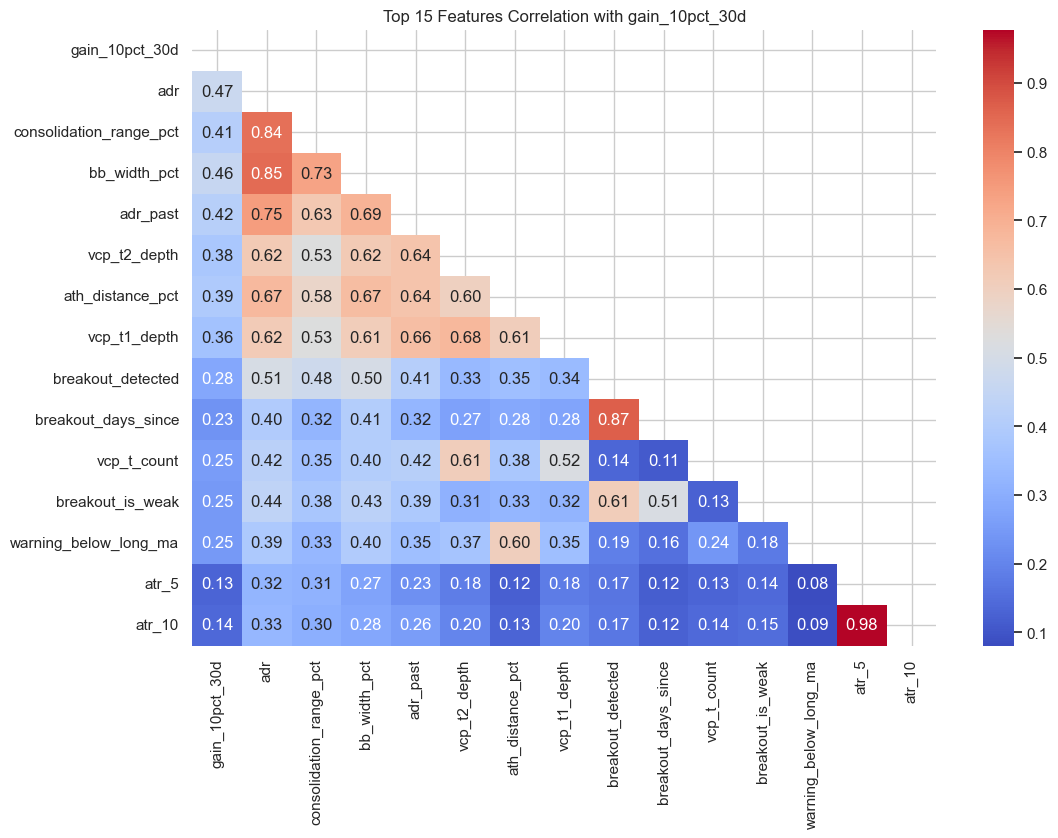

In [ ]:
# Identify the top 15 features with the highest positive correlation to the target
top_corr_features = corr[target_col].sort_values(ascending=False).head(15).index

# Generate a correlation matrix specifically for these top 15 features
top_corr_matrix = df[top_corr_features].corr()

# Visualize the correlations using a heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool)) # Create a mask to hide the upper triangle (removes redundant mirror data)
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask= mask)
plt.title(f"Top 15 Features Correlation with {target_col}")
plt.show()

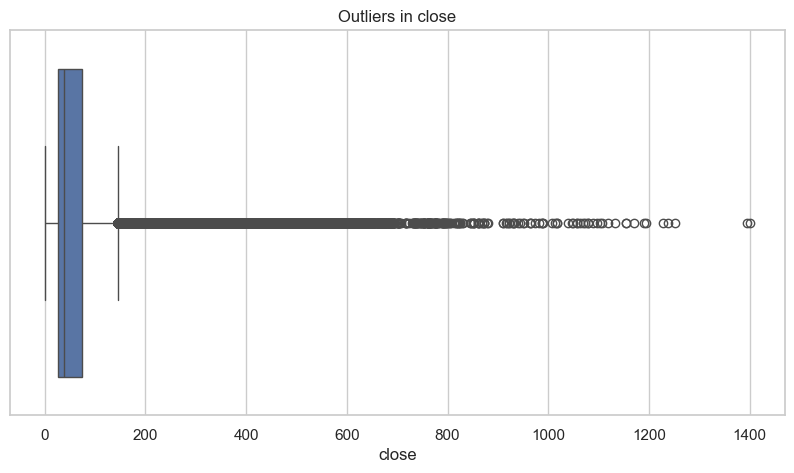

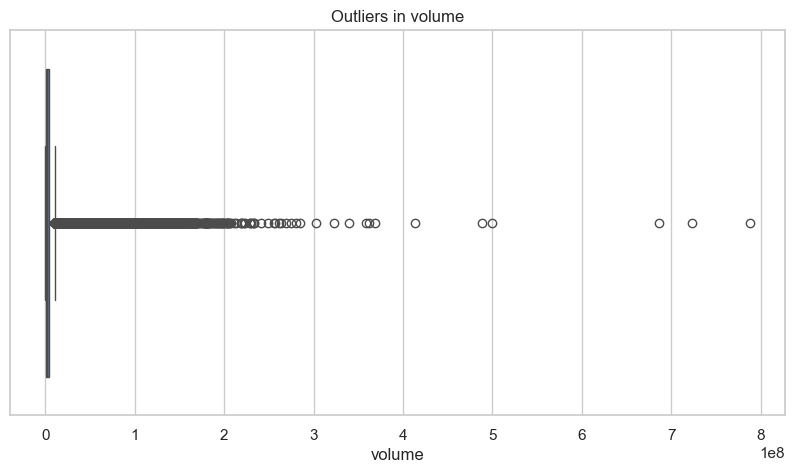

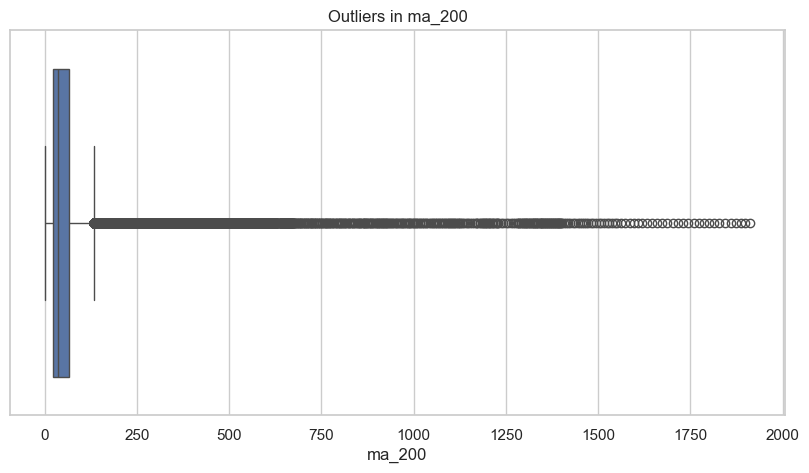

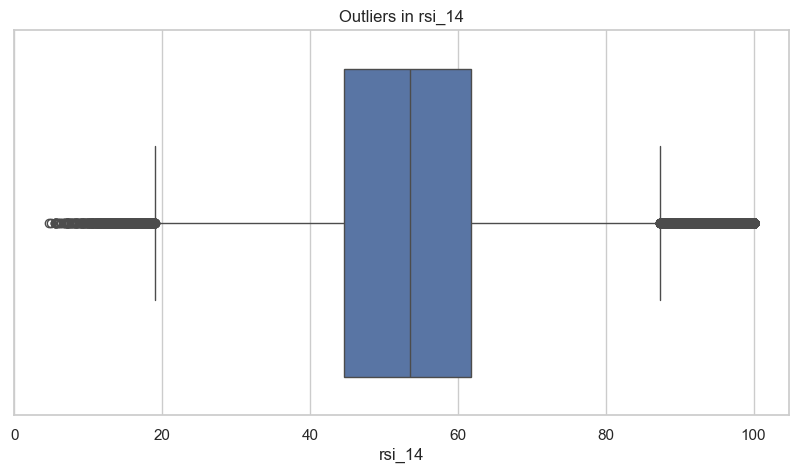

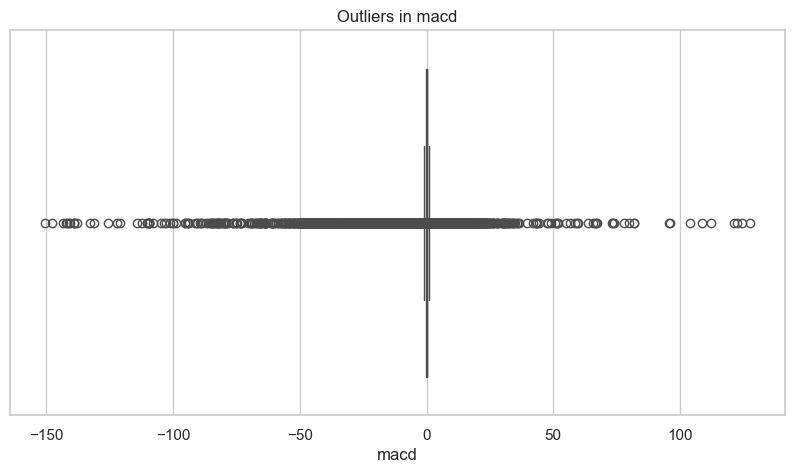

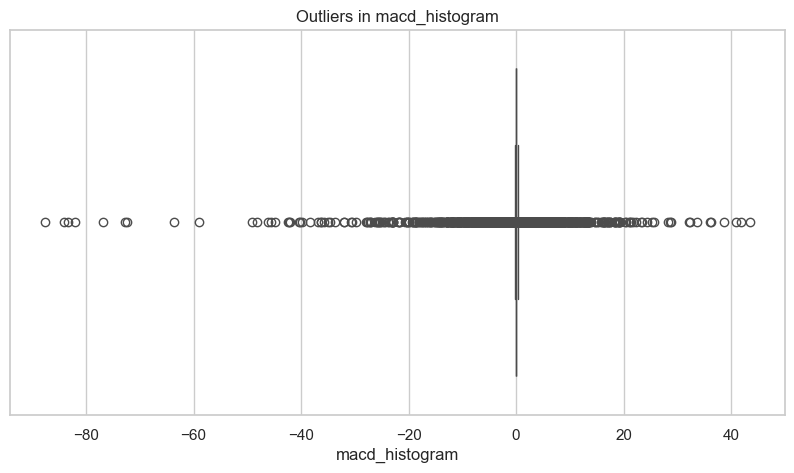

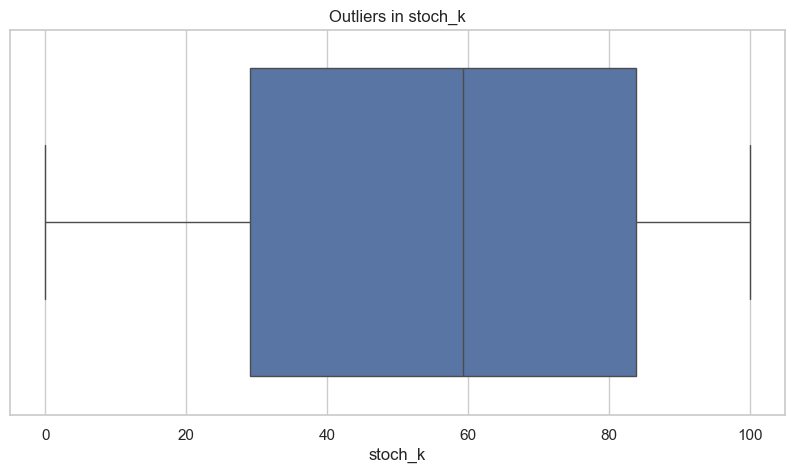

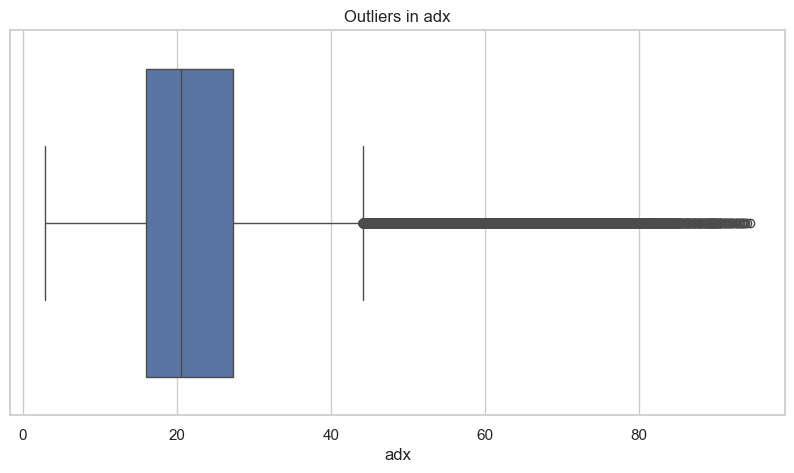

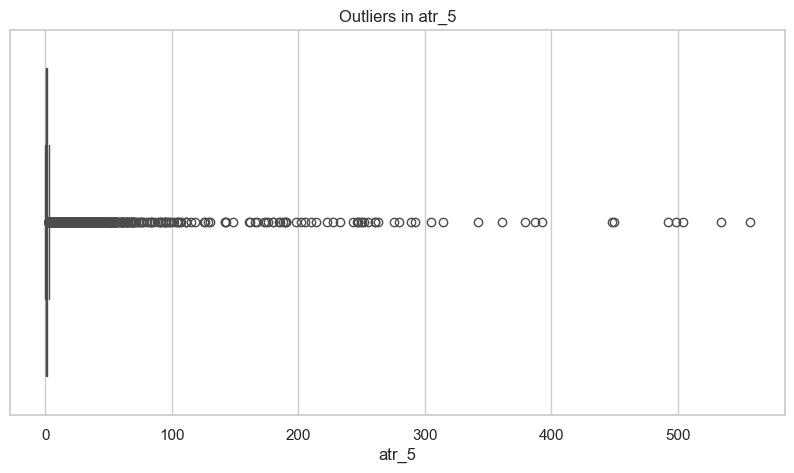

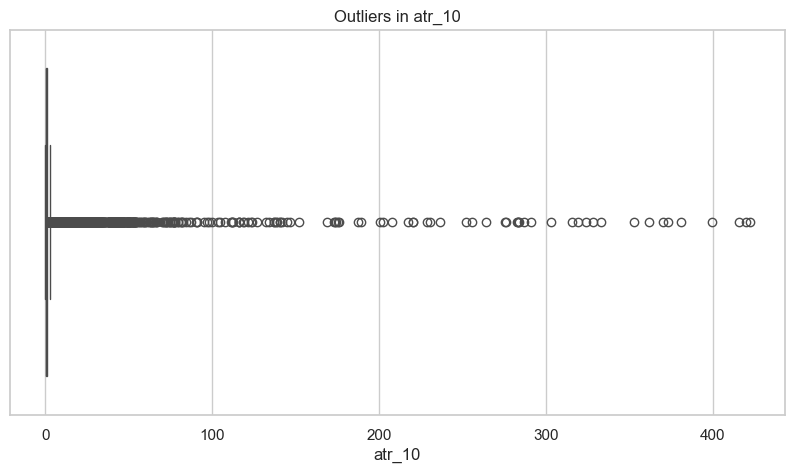

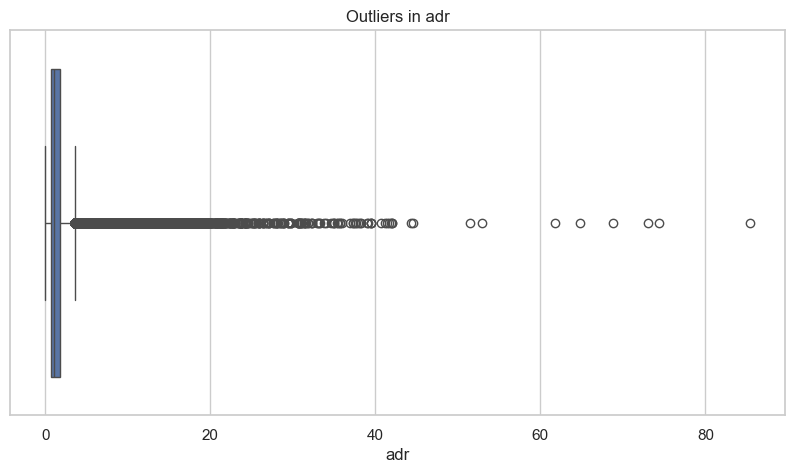

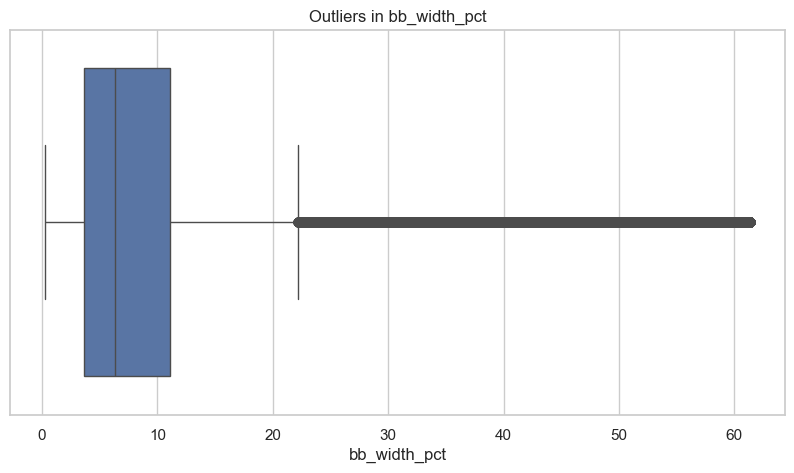

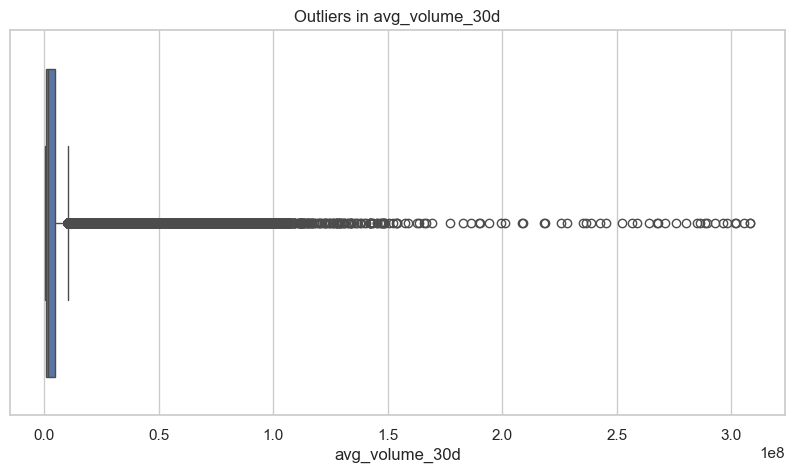

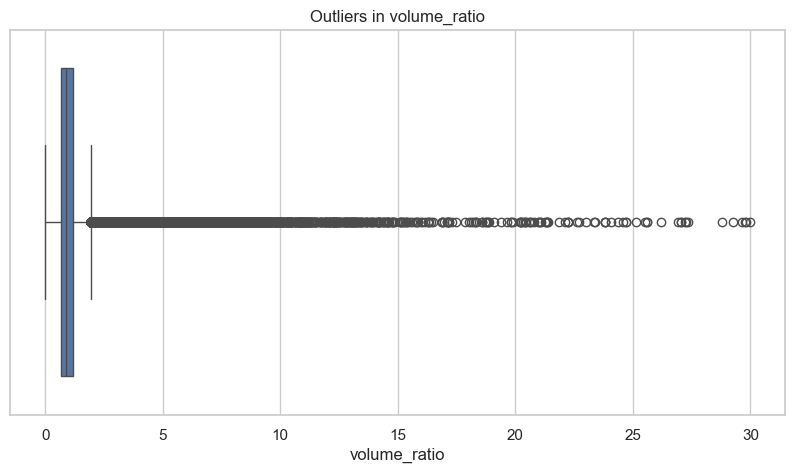

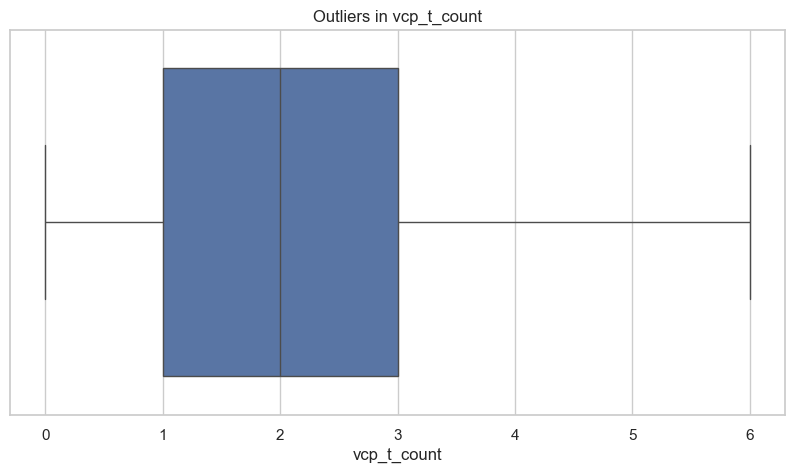

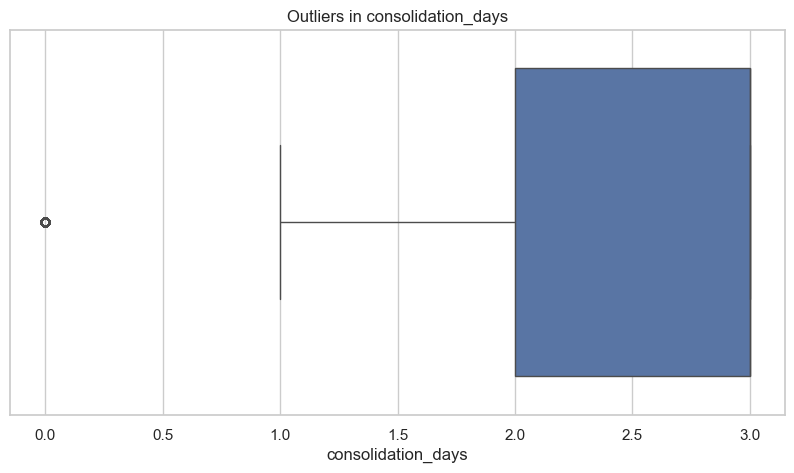

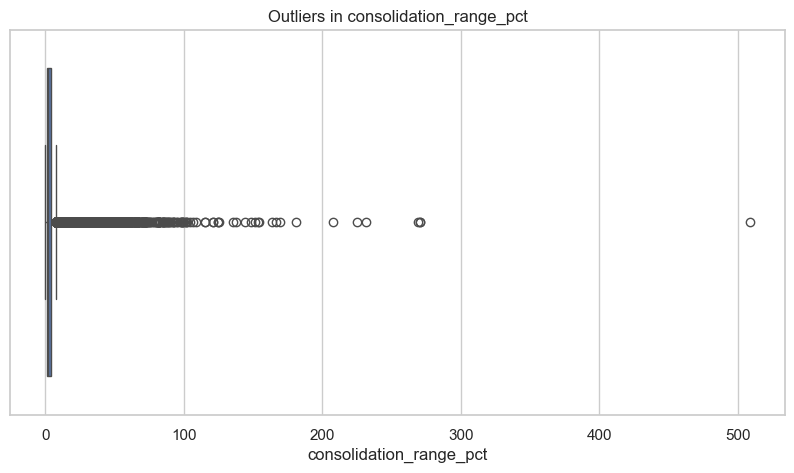

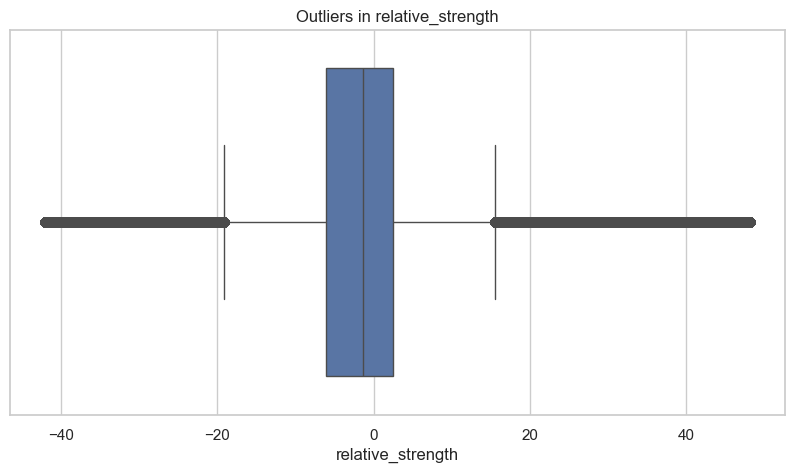

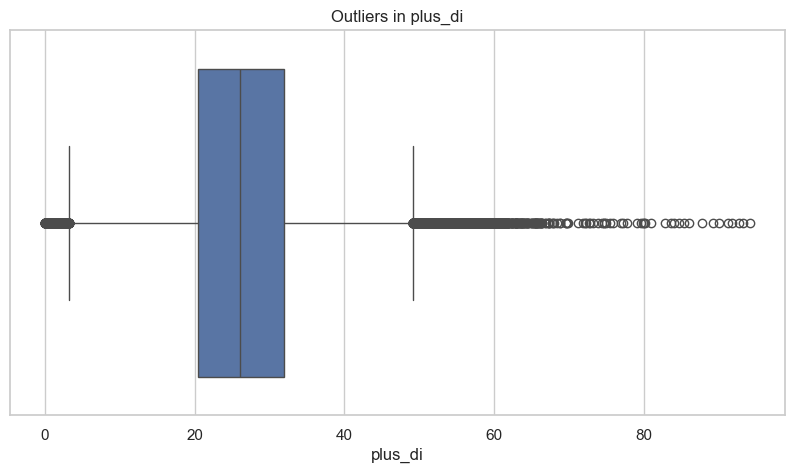

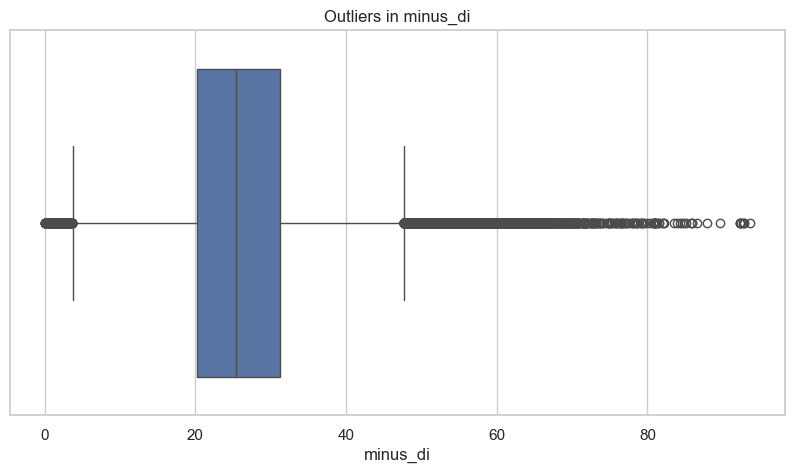

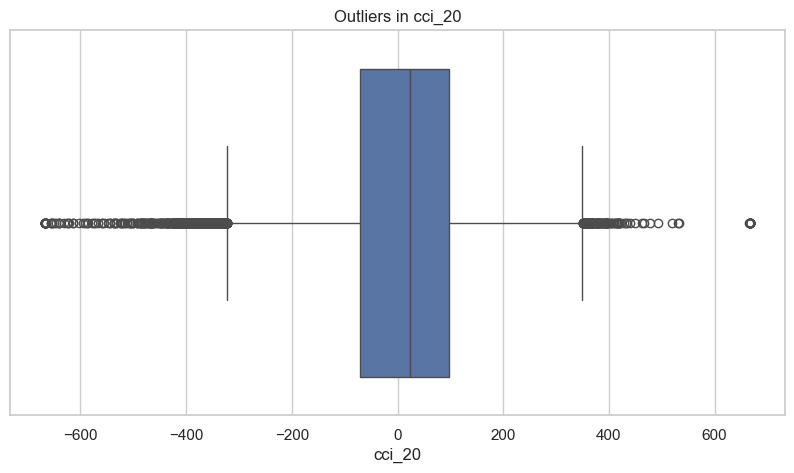

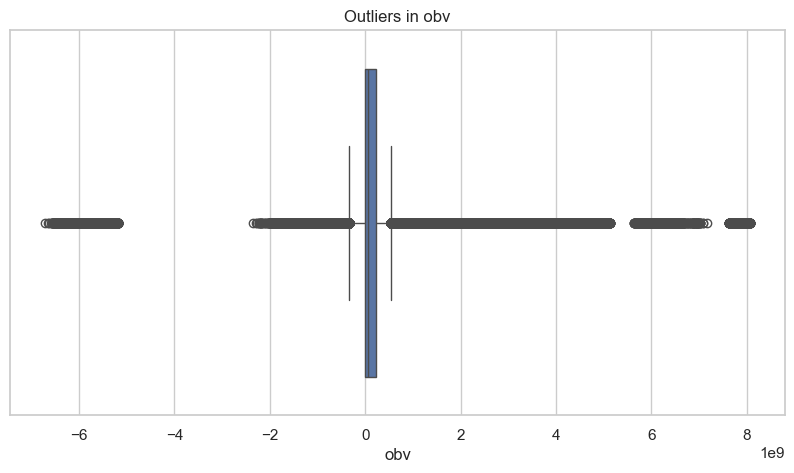

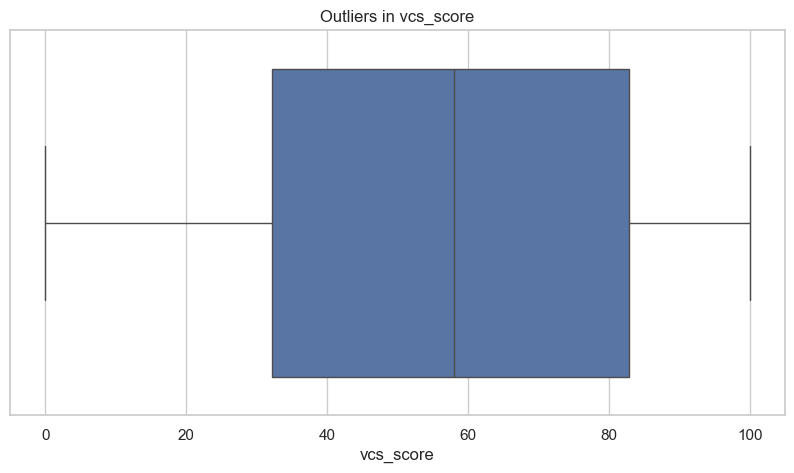

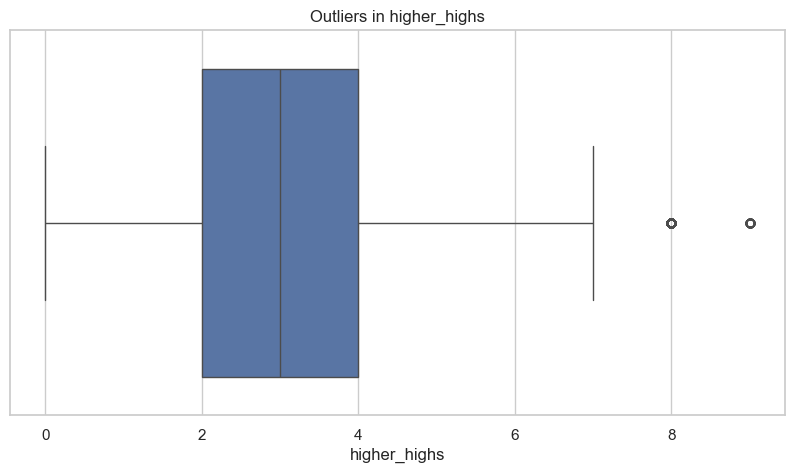

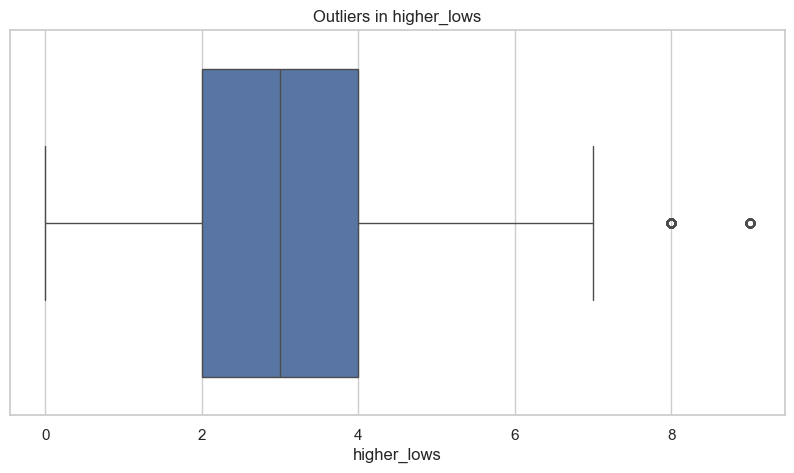

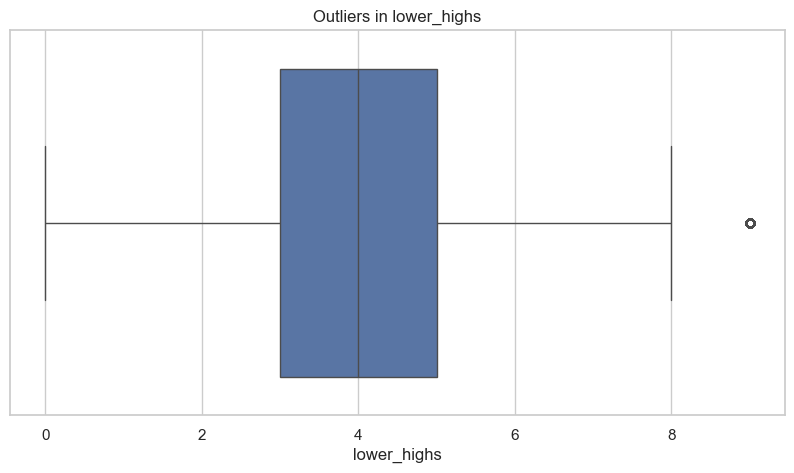

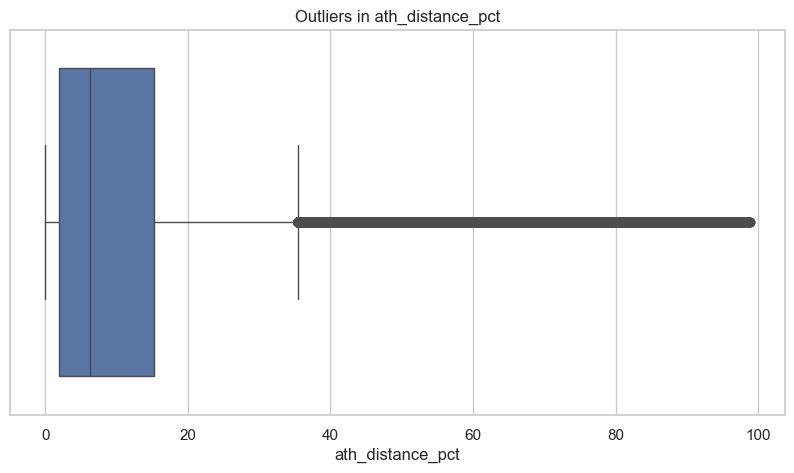

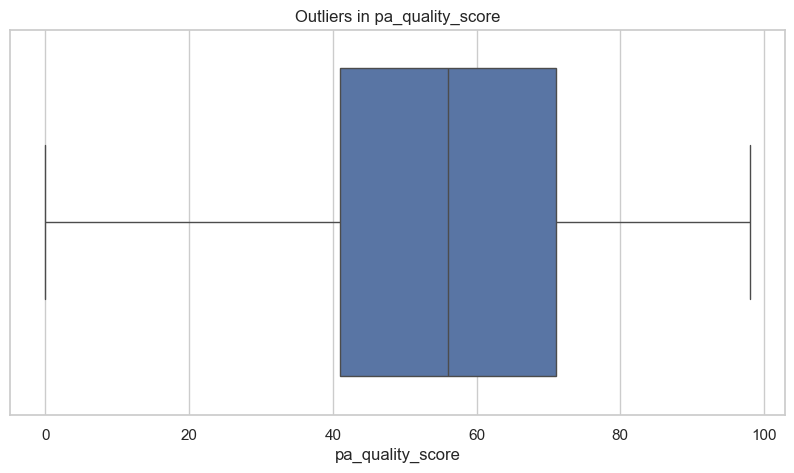

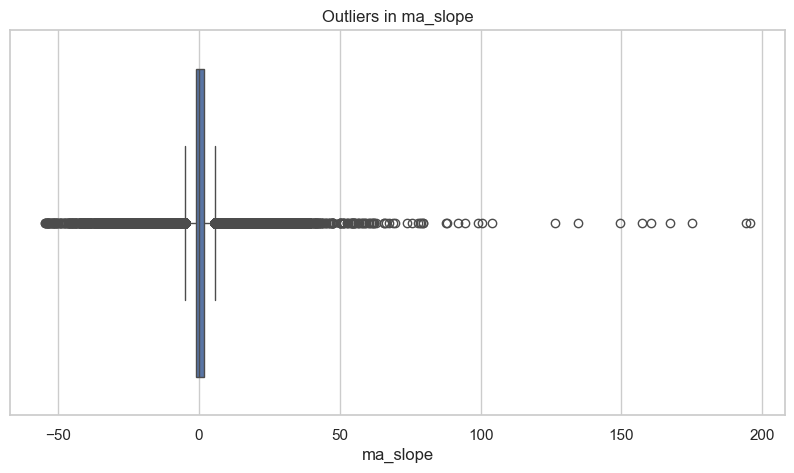

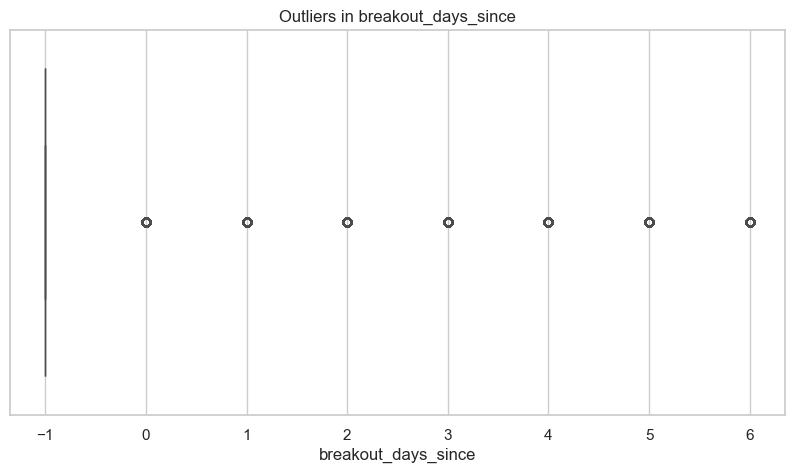

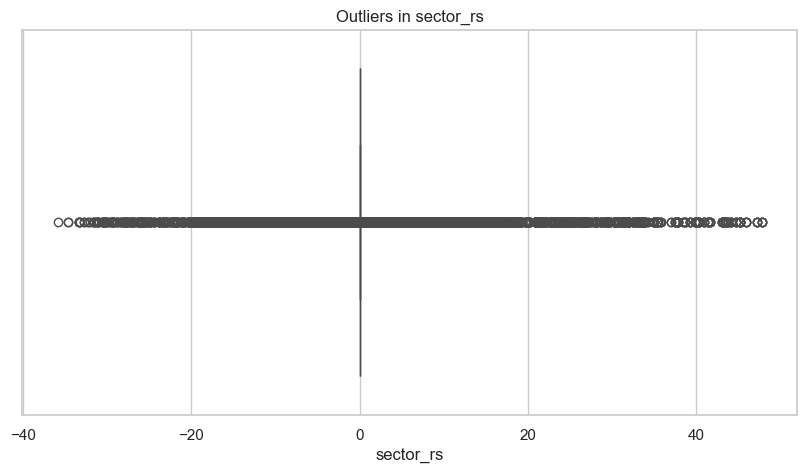

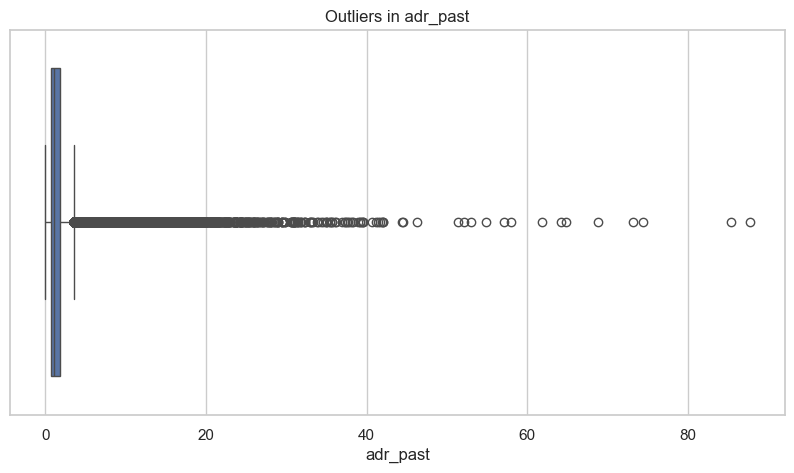

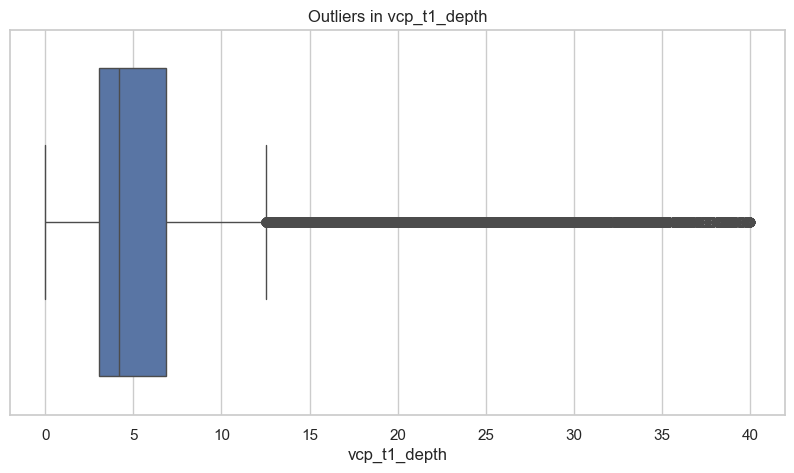

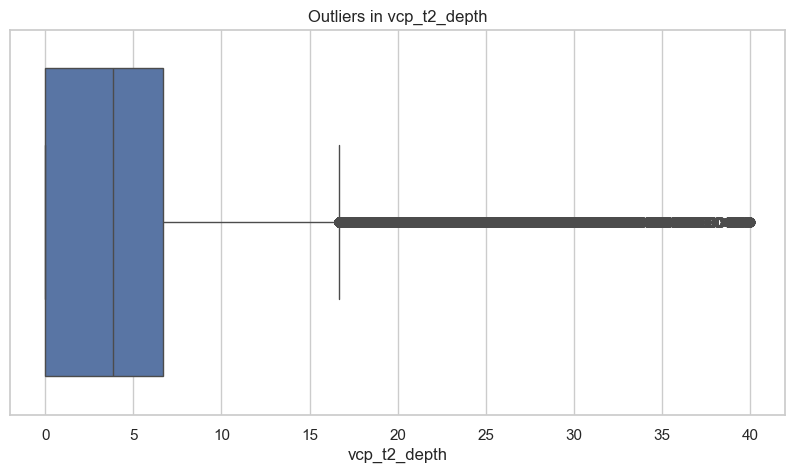

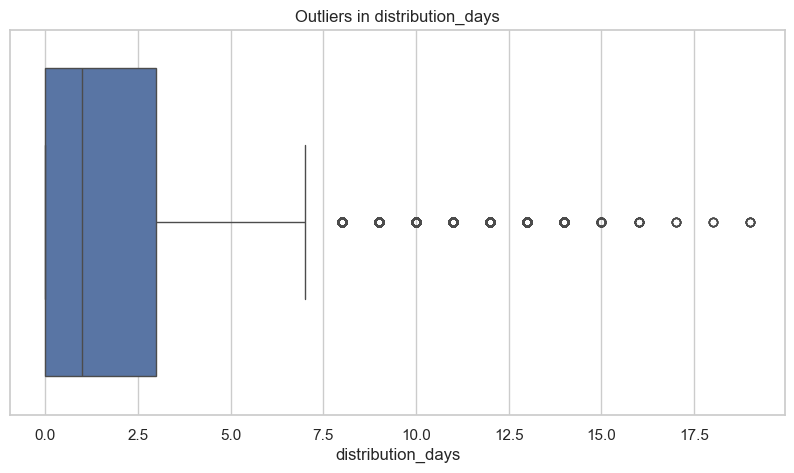

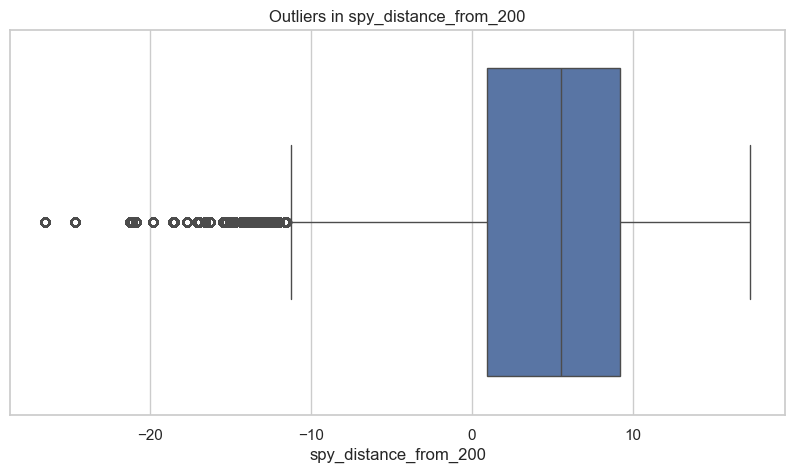

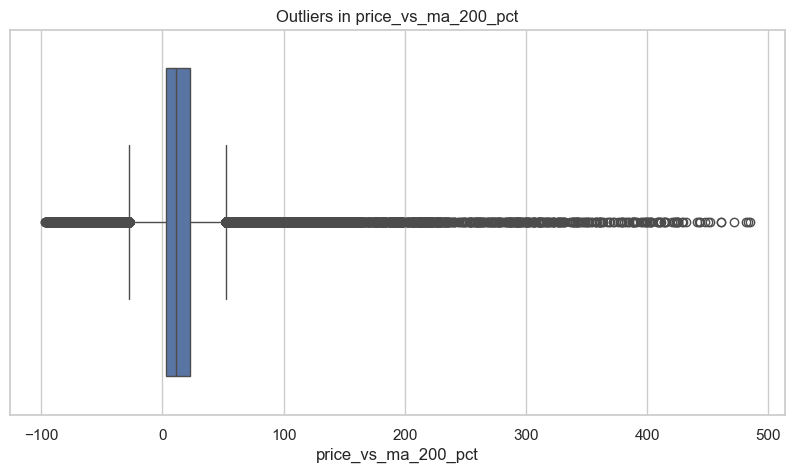

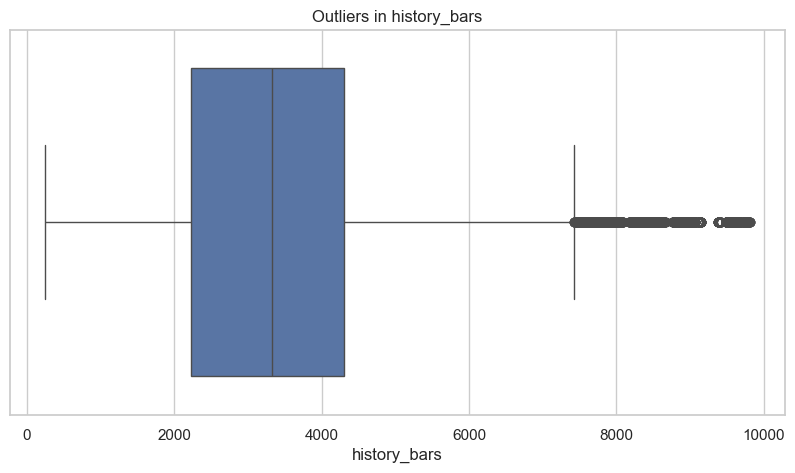

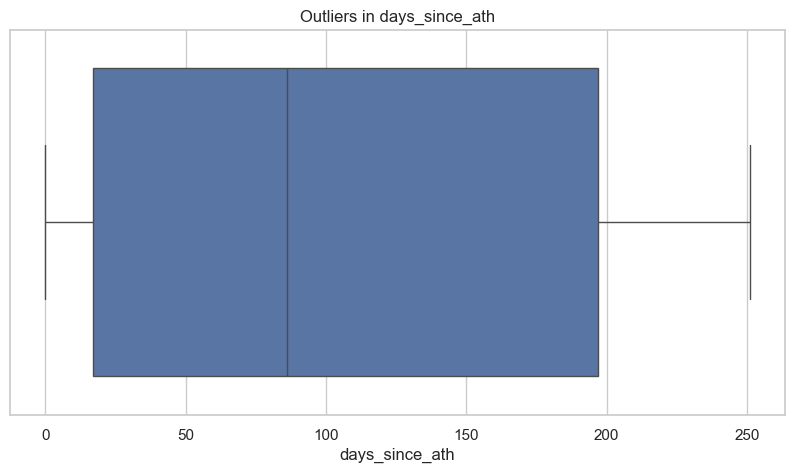

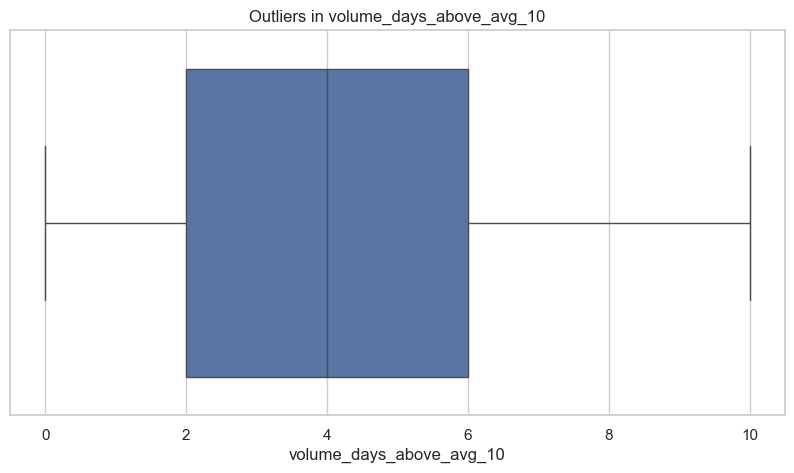

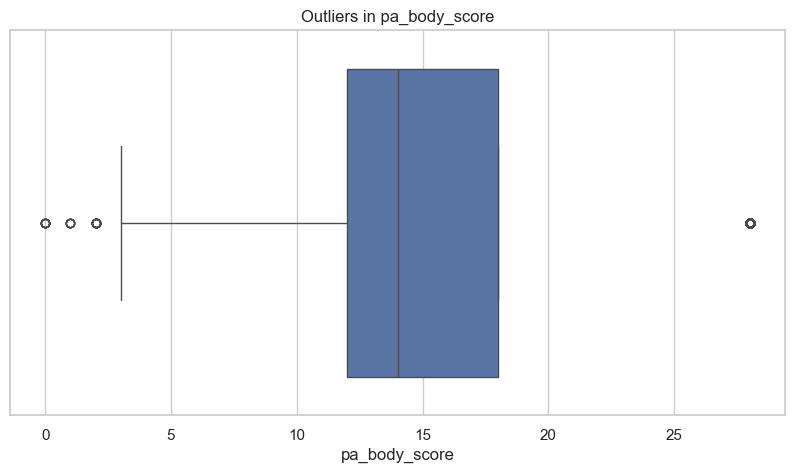

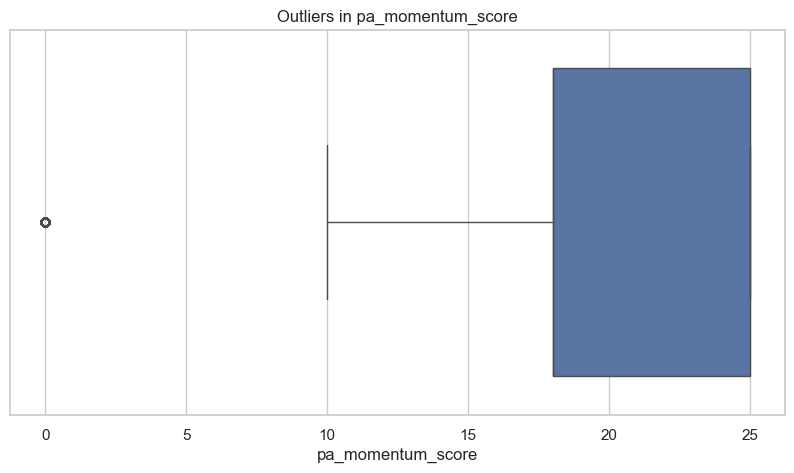

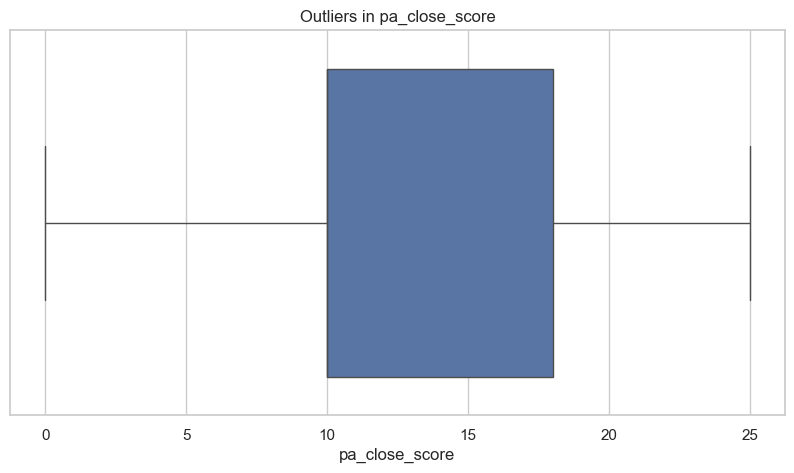

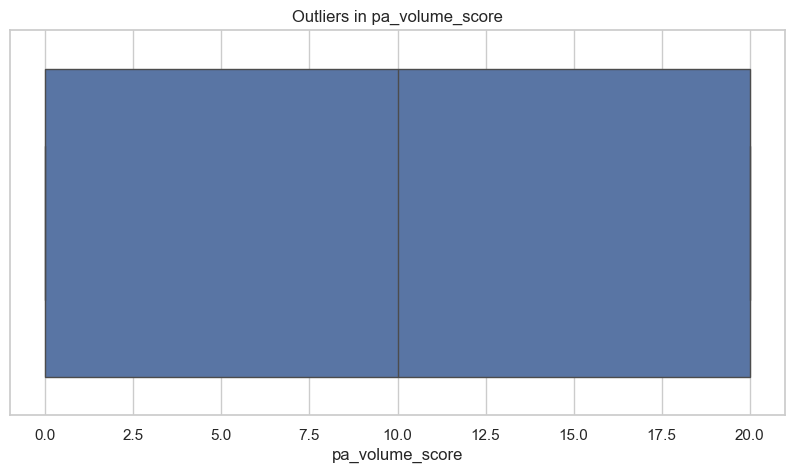

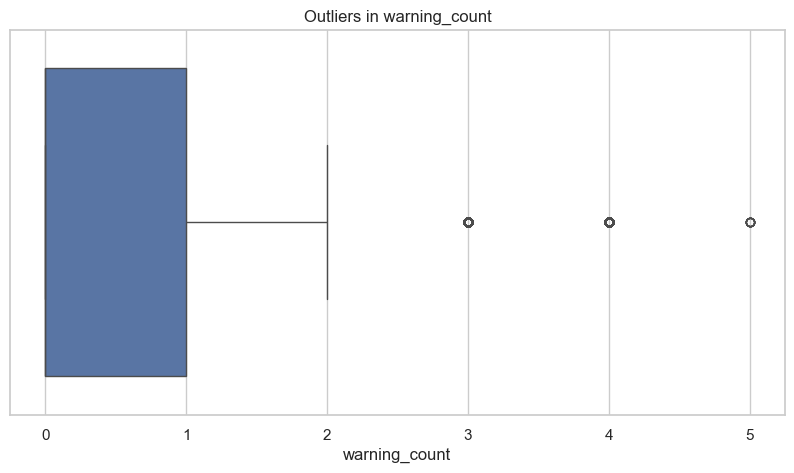

In [ ]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

## §4. Statistical Analysis

Statistical Analysis: Independent Samples T-Test (Numeric Features)
Objective: Determine if there is a statistically significant difference in the mean values of numeric features between "Successful" (gain_10pct_30d = True) and "Failed" trades.


In [ ]:
"""
Statistical Significance: Cohen's d (Effect Size)
While the **P-Value** tells us if a difference between groups exists, **Cohen's d** measures the **magnitude** of that difference in terms of standard deviations.

In large datasets (like this one with 600k+ rows), even tiny differences can become statistically significant (P ≈ 0). Cohen's d helps us identify which features have a **practical** impact on the target variable (`gain_10pct_30d`).

**Interpretation Scale:**
*   **Small Effect:** $d \approx 0.2$
*   **Medium Effect:** $d \approx 0.5$
*   **Large Effect:** $d \approx 0.8$
*   **Very Large Effect:** $d > 1.0$

*Note: A positive d-score indicates the mean is higher for successful trades, while a negative d-score indicates it is lower.*
"""


# We use Welch's T-Test (equal_var=False) to account for potential differences in group variances.


# Set pandas display to show scientific notation for small numbers
pd.options.display.float_format = '{:.6e}'.format

# Identify numeric columns for analysis
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
# Filter out time-related or identifier columns if necessary
numeric_features = [col for col in numeric_features if col not in ['year', 'month', 'day']]

t_test_results = []

for col in numeric_features:
    # Separate the data into two groups based on the target variable
    group_success = df[df['gain_10pct_30d'] == True][col].dropna()
    group_failure = df[df['gain_10pct_30d'] == False][col].dropna()

    # Ensure both groups have enough data points for a valid test
    if len(group_success) < 2 or len(group_failure) < 2:
        continue

    # Perform Welch's T-Test
    t_stat, p_val = ttest_ind(group_success, group_failure, equal_var=False)

    # Calculate Cohen's d (Effect Size) to measure the practical significance
    mean_diff = group_success.mean() - group_failure.mean()
    pooled_std = np.sqrt((group_success.std()**2 + group_failure.std()**2) / 2)
    cohen_d = mean_diff / pooled_std if pooled_std != 0 else 0

    t_test_results.append({
        'Feature': col,
        'T-Statistic': t_stat,
        'P-Value': p_val,
        'Effect Size (Cohen\'s d)': cohen_d,
        'Success Mean': group_success.mean(),
        'Failure Mean': group_failure.mean()
    })

# Convert to DataFrame and sort by the absolute value of Effect Size
t_test_df = pd.DataFrame(t_test_results).sort_values(by='Effect Size (Cohen\'s d)', key=abs, ascending=False)

print("Top 15 Numeric Features by Effect Size (Cohen's d):")
display(t_test_df.head(15))

Top 15 Numeric Features by Effect Size (Cohen's d):


,Feature,T-Statistic,P-Value,Effect Size (Cohen's d),Success Mean,Failure Mean
11,bb_width_pct,2.311975e+02,0.000000e+00,1.213634e+00,2.177392e+01,7.663498e+00
10,adr,2.223424e+02,0.000000e+00,1.187300e+00,3.835093e+00,1.285929e+00
33,vcp_t2_depth,2.206468e+02,0.000000e+00,1.100308e+00,1.094504e+01,3.948210e+00
26,ath_distance_pct,2.116757e+02,0.000000e+00,1.083091e+00,2.892208e+01,9.653476e+00
31,adr_past,1.996532e+02,0.000000e+00,1.056027e+00,3.625817e+00,1.315995e+00
32,vcp_t1_depth,2.052256e+02,0.000000e+00,1.029974e+00,1.100003e+01,4.646495e+00
16,consolidation_range_pct,1.757548e+02,0.000000e+00,9.535270e-01,8.450864e+00,2.780494e+00
14,vcp_t_count,2.286608e+02,0.000000e+00,9.163191e-01,3.290676e+00,1.937998e+00
44,warning_count,1.358376e+02,0.000000e+00,6.446275e-01,8.971476e-01,3.843367e-01
29,breakout_days_since,1.037213e+02,0.000000e+00,5.491074e-01,-2.111760e-02,-8.305962e-01


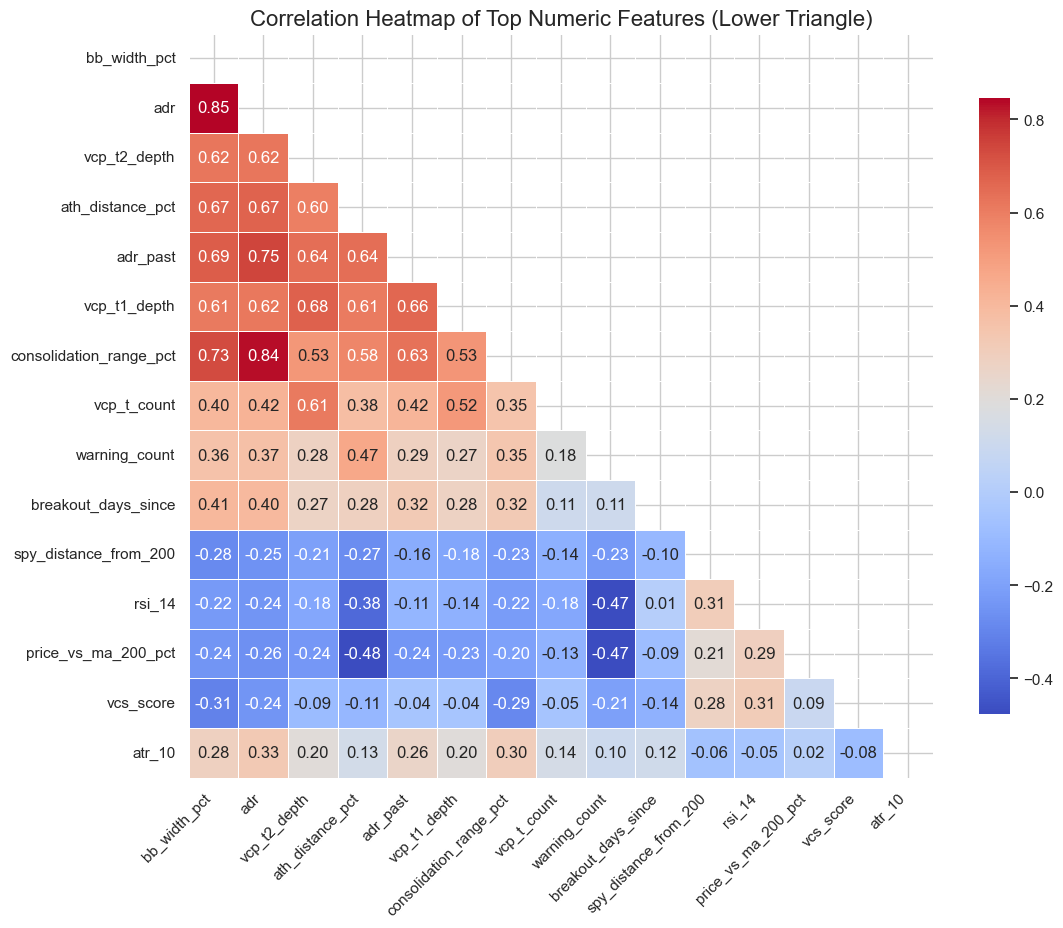

In [ ]:
## Correlation Analysis: Triangular Heatmap
# Objective: Visualize the linear relationships between numeric features.
# A triangular mask is applied to remove redundant information and improve readability.

# 1. Select numeric features for correlation
# We focus on the most important features identified earlier to avoid a cluttered map
top_numeric_features = t_test_df.head(15)['Feature'].tolist()
corr_matrix = df[top_numeric_features].corr()

# 2. Create a mask to hide the upper triangle
# np.triu returns the upper triangle of an array, which we use as a mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Setup the matplotlib figure
plt.figure(figsize=(12, 10))

# 4. Draw the heatmap
# cmap: 'coolwarm' is excellent for showing positive (red) and negative (blue) correlations
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Top Numeric Features (Lower Triangle)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

Statistical Analysis: Chi-Square Test of Independence (Categorical Features);
Objective: Test whether there is a significant association between categorical features and the target variable (gain_10pct_30d).
We also calculate Cramér's V to measure the strength of the association (Effect Size).

In [ ]:
"""
Statistical Association: Cramér's V
**Cramér's V** is a measure of association between two nominal (categorical) variables. It is used as a post-test for the **Chi-Square** test to determine the strength of the relationship between a categorical feature and the target variable.

Unlike the Chi-Square statistic, Cramér's V is normalized between **0 and 1**, making it independent of the sample size. This is crucial for evaluating categorical predictors in our dataset.

**Interpretation Scale:**
*   **0.0 - 0.1:** Negligible/Weak association.
*   **0.1 - 0.3:** Small to Moderate association.
*   **0.3 - 0.5:** Moderate to Strong association.
*   **> 0.5:** Very Strong association.

*A higher Cramér's V indicates that the categorical feature is a stronger predictor of the trade outcome.*
"""

# Identify categorical/boolean columns (excluding the target itself)
cat_features = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
cat_features = [col for col in cat_features if col not in ['gain_10pct_30d', 'symbol', 'date']]

chi_results = []

for col in cat_features:
    # Create a frequency table (contingency table)
    contingency_table = pd.crosstab(df[col], df['gain_10pct_30d'])

    # Skip features with insufficient variation
    if contingency_table.size < 4:
        continue

    # Perform Chi-Square Test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Calculate Cramér's V (Effect Size for categories)
    # Range: 0 (no association) to 1 (perfect association)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    chi_results.append({
        'Feature': col,
        'Chi2-Statistic': chi2,
        'P-Value': p,
        'Cramér\'s V': v_cramer
    })

# Convert to DataFrame and sort by Cramér's V
chi_df = pd.DataFrame(chi_results).sort_values(by='Cramér\'s V', ascending=False)

print("Categorical Features Analysis (Sorted by Cramér's V):")
display(chi_df)

Categorical Features Analysis (Sorted by Cramér's V):


,Feature,Chi2-Statistic,P-Value,Cramér's V
6,breakout_detected,4.565957e+04,0.000000e+00,2.812079e-01
8,breakout_is_weak,3.563973e+04,0.000000e+00,2.484442e-01
35,warning_below_long_ma,3.492424e+04,0.000000e+00,2.459377e-01
17,above_long_ma,3.471519e+04,0.000000e+00,2.452005e-01
19,slope_category,3.259231e+04,0.000000e+00,2.375851e-01
11,sector_leading,1.813821e+04,0.000000e+00,1.772388e-01
3,is_consolidating,1.770848e+04,0.000000e+00,1.751267e-01
18,vcp_state,1.732998e+04,0.000000e+00,1.732450e-01
7,breakout_is_strong,1.555450e+04,0.000000e+00,1.641306e-01
10,market_regime,1.461577e+04,0.000000e+00,1.591008e-01


## §5. Feature Selection and Removal Strategy
This section consolidates all identified low-information columns and highly correlated pairs to develop a feature removal strategy. Features that are both low-information and highly correlated will be automatically removed. For highly correlated pairs where neither feature is low-information, you will be prompted to choose one to remove.

In [ ]:
#Filter known data-error rows
n_before = len(df)

# RGTX: ma_200 far above close => split-adjustment failure on historical MA
rgtx = df["ma_200"].notna() & (df["ma_200"] > 5 * df["close"])
df   = df[~rgtx].copy()
print(f"Step 2: Filtered {rgtx.sum()} RGTX rows (ma_200 > 5x close)")

# JAVA: spy_distance_from_200 impossibly high => calculation bug
java = df["spy_distance_from_200"].notna() & (df["spy_distance_from_200"] > 50)
df   = df[~java].copy()
print(f"Step 2: Filtered {java.sum()} JAVA rows (spy_distance_from_200 > 50%)")
print(f"        Rows removed total: {n_before - len(df):,}  |  Remaining: {len(df):,}")

Step 2: Filtered 415 RGTX rows (ma_200 > 5x close)
Step 2: Filtered 0 JAVA rows (spy_distance_from_200 > 50%)
        Rows removed total: 415  |  Remaining: 576,985


In [ ]:
# ── Drop rows where target is null ────────────────────────────────────

TARGET      = "gain_10pct_30d"

n_before = len(df)
df = df[df[TARGET].notna()].copy()
print(f"Step 3: Dropped {n_before - len(df):,} target-null rows  |  Remaining: {len(df):,}")

Step 3: Dropped 0 target-null rows  |  Remaining: 576,985


In [ ]:
# feature correlation detection

import numpy as np

numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr(method='spearman').abs()

pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        feature1 = correlation_matrix.columns[i]
        feature2 = correlation_matrix.columns[j]
        r_value = correlation_matrix.iloc[i, j]
        pairs.append({'feature1': feature1, 'feature2': feature2, 'r_value': r_value})

correlation_pairs_df = pd.DataFrame(pairs)

def tag_correlation(r):
    if r >= 0.99:
        return 'very highly correlated'
    elif r >= 0.8:
        return 'high'
    elif r >= 0.7:
        return 'moderate'
    else:
        return 'low'

correlation_pairs_df['correlation_tag'] = correlation_pairs_df['r_value'].apply(tag_correlation)

print("Feature Correlation Examination Results (Spearman):")
print(correlation_pairs_df.sort_values(by='r_value', ascending=False).head(20)) # Display top 20 correlations
print("\nCorrelation Tag Counts:")
print(correlation_pairs_df['correlation_tag'].value_counts())

Feature Correlation Examination Results (Spearman):
                    feature1                 feature2      r_value         correlation_tag
324                    atr_5                   atr_10 9.953709e-01  very highly correlated
1                      close                   ma_200 9.670987e-01                    high
852         pa_quality_score          pa_volume_score 9.061274e-01                    high
54                    volume           avg_volume_30d 9.043043e-01                    high
262                  stoch_k                   cci_20 8.993444e-01                    high
400                      adr  consolidation_range_pct 8.947721e-01                    high
850         pa_quality_score        pa_momentum_score 8.903906e-01                    high
415                      adr                 adr_past 8.677850e-01                    high
145                   rsi_14                   cci_20 8.659527e-01                    high
395                      adr          

In [ ]:
# Identify boolean/binary-like numeric columns with >95% same value
low_information_binary_columns = []

for col in df.columns:
    # Check for boolean type directly
    if pd.api.types.is_bool_dtype(df[col]):
        value_counts = df[col].value_counts(normalize=True)
        if not value_counts.empty and value_counts.max() > 0.95:
            low_information_binary_columns.append(col)
    # Check for numeric type that might act as binary (e.g., 0/1, 0/100, True/False represented numerically)
    elif pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() <= 2:
        # Check if the unique values are consistent with binary representation (0, 1, or NaN)
        unique_vals = df[col].dropna().unique()
        if all(val in [0, 1] for val in unique_vals):
            value_counts = df[col].value_counts(normalize=True)
            if not value_counts.empty and value_counts.max() > 0.9:
                low_information_binary_columns.append(col)

print("Columns with boolean/binary-like data having >90% of a single value:")
if low_information_binary_columns:
    for col in low_information_binary_columns:
        print(f"- {col}")
else:
    print("No such columns found.")

Columns with boolean/binary-like data having >90% of a single value:
- is_consolidating
- rsi_pullback
- breakout_is_strong
- breakout_is_weak
- breakout_is_suspicious
- strong_uptrend
- sector_leading
- vcp_is_valid
- is_biotech
- warning_extended_move
- warning_gap_down
- warning_failed_breakout
- warning_broke_fast_ma


In [ ]:
#features that have '0' or 'null' in more than 95% of their records.
low_information_zero_or_null_columns = []

for col in df.columns:
    total_rows = len(df)
    # Count NaN values
    nan_count = df[col].isnull().sum()

    # Count zero values (only if the column is numeric and not NaN)
    zero_count = 0
    if pd.api.types.is_numeric_dtype(df[col]):
        zero_count = (df[col] == 0).sum()

    # Sum of NaNs and Zeros
    zero_or_null_count = nan_count + zero_count

    # Calculate proportion
    proportion_zero_or_null = zero_or_null_count / total_rows

    if proportion_zero_or_null > 0.95:
        low_information_zero_or_null_columns.append(col)

print("Columns with more than 95% zeros or null values:")
if low_information_zero_or_null_columns:
    for col in low_information_zero_or_null_columns:
        print(f"- {col}")
else:
    print("No such columns found.")

Columns with more than 95% zeros or null values:
- rsi_pullback
- breakout_is_strong
- sector_rs
- breakout_is_weak
- breakout_is_suspicious
- strong_uptrend
- sector_leading
- vcp_is_valid
- is_biotech
- warning_extended_move
- warning_gap_down
- warning_failed_breakout
- warning_broke_fast_ma


In [ ]:
# Combine all low-information columns
combined_low_information_cols = set(low_information_zero_or_null_columns).union(set(low_information_binary_columns))

engine_features = {
    "total_score", "final_score",
    "liquidity_score",      # also Tier A
    "trend_score", "performance_score", "setup_score", "risk_penalty",
    "expected_move", "expected_move_pct",
    "signal_strength", "risk_level"
}

combined_low_information_cols = combined_low_information_cols.union(engine_features)

# Identify highly correlated pairs (r >= 0.8)
highly_correlated_df_filtered = correlation_pairs_df[
    (correlation_pairs_df['correlation_tag'] == 'very highly correlated') |
    (correlation_pairs_df['correlation_tag'] == 'high')
].copy()

# Initialize sets for final decisions
columns_to_remove_automatically = set(combined_low_information_cols)
interactive_correlation_pairs_for_user = []
resolved_from_correlation = set()

# Process each highly correlated pair to categorize features
for index, row in highly_correlated_df_filtered.iterrows():
    f1 = row['feature1']
    f2 = row['feature2']
    r_value = row['r_value']

    f1_is_low_info = f1 in combined_low_information_cols
    f2_is_low_info = f2 in combined_low_information_cols

# check if correlated features are already in the combined_low_information_cols list
    if f1_is_low_info and not f2_is_low_info:
        columns_to_remove_automatically.add(f1)
        resolved_from_correlation.add(f1)
        resolved_from_correlation.add(f2)
    elif f2_is_low_info and not f1_is_low_info:
        columns_to_remove_automatically.add(f2)
        resolved_from_correlation.add(f1)
        resolved_from_correlation.add(f2)
    elif f1_is_low_info and f2_is_low_info:
        columns_to_remove_automatically.add(f1)
        columns_to_remove_automatically.add(f2)
        resolved_from_correlation.add(f1)
        resolved_from_correlation.add(f2)
    else:
        if f1 not in resolved_from_correlation and f2 not in resolved_from_correlation:
            interactive_correlation_pairs_for_user.append((f1, f2, r_value))
            resolved_from_correlation.add(f1)
            resolved_from_correlation.add(f2)

print("--- Feature Removal Strategy Summary ---")
print("\nColumns identified for automatic removal (low-information or highly correlated with a low-information feature):")
if columns_to_remove_automatically:
    for col in sorted(list(columns_to_remove_automatically)):
        print(f"- {col}")
else:
    print("No columns identified for automatic removal.")

print("\nHighly correlated pairs requiring user decision:")
if interactive_correlation_pairs_for_user:
    print("For each pair, you will be asked to indicate which feature to remove:")
    for f1, f2, r_value in interactive_correlation_pairs_for_user:
        print(f"- Pair: '{f1}' and '{f2}' (Correlation: {r_value:.2f})")
else:
    print("No highly correlated pairs require explicit user decision.")

--- Feature Removal Strategy Summary ---

Columns identified for automatic removal (low-information or highly correlated with a low-information feature):
- breakout_is_strong
- breakout_is_suspicious
- breakout_is_weak
- expected_move
- expected_move_pct
- final_score
- is_biotech
- is_consolidating
- liquidity_score
- performance_score
- risk_level
- risk_penalty
- rsi_pullback
- sector_leading
- sector_rs
- setup_score
- signal_strength
- strong_uptrend
- total_score
- trend_score
- vcp_is_valid
- warning_broke_fast_ma
- warning_extended_move
- warning_failed_breakout
- warning_gap_down

Highly correlated pairs requiring user decision:
For each pair, you will be asked to indicate which feature to remove:
- Pair: 'close' and 'ma_200' (Correlation: 0.97)
- Pair: 'volume' and 'avg_volume_30d' (Correlation: 0.90)
- Pair: 'rsi_14' and 'stoch_k' (Correlation: 0.81)
- Pair: 'macd' and 'ma_slope' (Correlation: 0.85)
- Pair: 'atr_5' and 'atr_10' (Correlation: 1.00)
- Pair: 'adr' and 'bb_width

In [ ]:
columns_to_remove_by_user_choice = set()

if interactive_correlation_pairs_for_user:
    print("Automatically removing the second feature ('f2') for each highly correlated pair.")

    for f1, f2, r_value in interactive_correlation_pairs_for_user:
        columns_to_remove_by_user_choice.add(f2)
        print(f"Removed '{f2}' from pair ('{f1}', '{f2}') (Correlation: {r_value:.2f}).")
else:
    print("No highly correlated pairs require interactive selection.")

print("\n--- User-Selected Columns for Removal ---")
if columns_to_remove_by_user_choice:
    for col in sorted(list(columns_to_remove_by_user_choice)):
        print(f"- {col}")
else:
    print("No columns were selected for removal by the user.")

Automatically removing the second feature ('f2') for each highly correlated pair.
Removed 'ma_200' from pair ('close', 'ma_200') (Correlation: 0.97).
Removed 'avg_volume_30d' from pair ('volume', 'avg_volume_30d') (Correlation: 0.90).
Removed 'stoch_k' from pair ('rsi_14', 'stoch_k') (Correlation: 0.81).
Removed 'ma_slope' from pair ('macd', 'ma_slope') (Correlation: 0.85).
Removed 'atr_10' from pair ('atr_5', 'atr_10') (Correlation: 1.00).
Removed 'bb_width_pct' from pair ('adr', 'bb_width_pct') (Correlation: 0.85).
Removed 'higher_lows' from pair ('higher_highs', 'higher_lows') (Correlation: 0.84).
Removed 'pa_momentum_score' from pair ('pa_quality_score', 'pa_momentum_score') (Correlation: 0.89).

--- User-Selected Columns for Removal ---
- atr_10
- avg_volume_30d
- bb_width_pct
- higher_lows
- ma_200
- ma_slope
- pa_momentum_score
- stoch_k


In [ ]:
# Combine all columns identified for removal
final_columns_to_drop = columns_to_remove_automatically.union(columns_to_remove_by_user_choice)

print("--- Final List of ALL Columns to Be Dropped ---")
if final_columns_to_drop:
    for col in sorted(list(final_columns_to_drop)):
        print(f"- {col}")
else:
    print("No columns to drop based on the defined strategy.")

# Drop the identified columns from the DataFrame
df_ready = df.drop(columns=list(final_columns_to_drop), errors='ignore')
print(f"Step 1 -- dropped {len(final_columns_to_drop)} explicit cols -> {df_ready.shape[1]} remaining")


--- Final List of ALL Columns to Be Dropped ---
- atr_10
- avg_volume_30d
- bb_width_pct
- breakout_is_strong
- breakout_is_suspicious
- breakout_is_weak
- expected_move
- expected_move_pct
- final_score
- higher_lows
- is_biotech
- is_consolidating
- liquidity_score
- ma_200
- ma_slope
- pa_momentum_score
- performance_score
- risk_level
- risk_penalty
- rsi_pullback
- sector_leading
- sector_rs
- setup_score
- signal_strength
- stoch_k
- strong_uptrend
- total_score
- trend_score
- vcp_is_valid
- warning_broke_fast_ma
- warning_extended_move
- warning_failed_breakout
- warning_gap_down
Step 1 -- dropped 33 explicit cols -> 66 remaining


In [ ]:
IDENTIFIERS_to_keep = {"symbol", "exchange", "timestamp"}

# Step 2 --cast booleans to nullable Int8 (binary features become numeric)
bool_cols = [
    c for c in df_ready.columns
    if c not in IDENTIFIERS_to_keep
    and str(df_ready[c].dtype) in ("bool", "boolean")
]
for c in bool_cols:
    df_ready[c] = df_ready[c].astype("Int8")
print(f"\nStep 2 --cast {len(bool_cols)} bool cols to Int8:")
print(f"  {bool_cols}")

# Step 3 --drop remaining string non-identifier columns
def _is_string(s: pd.Series) -> bool:
    dtype_str = str(s.dtype)
    return (
        s.dtype == object
        or dtype_str in ("string", "str")
        or dtype_str.startswith("string[")
    )

str_non_id = [c for c in df_ready.columns if c not in IDENTIFIERS_to_keep and _is_string(df_ready[c])]
df_ready = df_ready.drop(columns=str_non_id)
print(f"\nStep 3 -- dropped {len(str_non_id)} remaining string cols -> {df_ready.shape[1]} remaining")
print(f"  {str_non_id}")

# ── Final column inventory ────────────────────────────────────────────────────
print(f"\nFinal shape: {df_ready.shape[0]:,} rows × {df_ready.shape[1]} cols")
print("\nFinal columns by dtype:")
for dtype_group, cols in df_ready.dtypes.groupby(df_ready.dtypes.astype(str)):
    names = list(cols.index)
    print(f"  {dtype_group}: {names}")

# Verify no non-numeric non-identifier columns remain
unexpected = [
    c for c in df_ready.columns
    if c not in IDENTIFIERS_to_keep
    and not pd.api.types.is_numeric_dtype(df_ready[c])
]
if unexpected:
    print(f"\nWARNING: non-numeric non-identifier cols still present: {unexpected}")
else:
    print("\nCheck passed: all non-identifier columns are numeric.")



Step 2 --cast 12 bool cols to Int8:
  ['distribution_detected', 'breakout_detected', 'stock_leading_sector', 'adr_declining', 'ma_alignment', 'above_fast_ma', 'above_long_ma', 'weekly_trend_partial_week', 'warning_below_fast_ma', 'warning_below_long_ma', 'warning_distribution', 'gain_10pct_30d']

Step 3 -- dropped 15 remaining string cols -> 51 remaining
  ['pa_quality_label', 'weekly_trend_status', 'market_regime', 'vcp_state', 'slope_category', 'volume_surge_label', 'rs_state', 'vcs_label', 'macd_state', 'stoch_state', 'adx_state', 'cci_state', 'obv_state', 'rsi_pullback_label', 'signal_type']

Final shape: 576,985 rows × 51 cols

Final columns by dtype:
  Int8: ['distribution_detected', 'breakout_detected', 'stock_leading_sector', 'adr_declining', 'ma_alignment', 'above_fast_ma', 'above_long_ma', 'weekly_trend_partial_week', 'warning_below_fast_ma', 'warning_below_long_ma', 'warning_distribution', 'gain_10pct_30d']
  datetime64[us, UTC]: ['timestamp']
  float64: ['close', 'volume',

In [ ]:
print("Applying one-hot encoding to 'exchange' column...")
df_ready = pd.get_dummies(df_ready, columns=['exchange'], prefix='exchange', dtype=int, drop_first=True)

Applying one-hot encoding to 'exchange' column...


### Null Detection and Handling

In [ ]:
# Handle high %null in 'above_long_ma' and 'above_fast_ma'
for col in ['above_long_ma', 'above_fast_ma']:
    # Create '_was_null' indicator column
    df_ready[f'{col}_was_null'] = df_ready[col].isnull().astype('Int8')
    # Impute original column NaN values with 0
    df_ready[col] = df_ready[col].fillna(0).astype('Int8')

print("Null values in 'above_long_ma' and 'above_fast_ma' have been processed.")
print("New indicator columns '_was_null' have been created.")
display(df_ready[['above_long_ma', 'above_long_ma_was_null', 'above_fast_ma', 'above_fast_ma_was_null']].head())

Null values in 'above_long_ma' and 'above_fast_ma' have been processed.
New indicator columns '_was_null' have been created.


,above_long_ma,above_long_ma_was_null,above_fast_ma,above_fast_ma_was_null
0,1,0,1,0
1,1,0,1,0
2,1,0,1,0
3,1,0,1,0
4,1,0,1,0


In [ ]:
# Detect missing values
missing_values = df_ready.isnull().sum()
missing_percentage = (missing_values / len(df_ready)) * 100

# Create a DataFrame to display missing information
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values and sort them
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("--- Missing Values Detection and Handling Suggestions ---")

if not missing_info.empty:
    for col, row in missing_info.iterrows():
        print(f"\nFeature: '{col}'")
        print(f"  Missing values: {int(row['Missing Count'])} ({row['Missing Percentage']:.2f}% of data)")

        # Suggest handling strategy based on percentage and data type
        if row['Missing Percentage'] > 50:
            print("  Suggested strategy: This feature has a very high percentage of missing values. Consider dropping the column if it's not critical, or if domain knowledge suggests imputation would be misleading. Advanced imputation methods might be considered if the feature is indispensable.")
        elif row['Missing Percentage'] > 20:
            print("  Suggested strategy: This feature has a significant percentage of missing values. Imputation with mean, median, or mode is an option, or using more sophisticated methods like K-Nearest Neighbors (KNN) imputation or MICE. Alternatively, consider creating an indicator column for missingness and then imputing.")
        elif row['Missing Percentage'] > 0:
            print("  Suggested strategy: This feature has a relatively low percentage of missing values. Simple imputation methods like mean, median, or mode can be effective. For categorical data, mode imputation is suitable. Removing rows with missing values for this feature is also an option if the dataset is large enough and the missingness is random.")
        else:
            print("  Suggested strategy: No missing values detected for this feature.")
else:
    print("No missing values found in the DataFrame.")

--- Missing Values Detection and Handling Suggestions ---
No missing values found in the DataFrame.


In [ ]:
# Dynamically identify columns for median imputation (all with missing values except 'relative_strength')
median_impute_cols = missing_info[missing_info.index != 'relative_strength'].index.tolist()

# Apply median imputation
for col in median_impute_cols:
    if col in df_ready.columns and df_ready[col].isnull().any():
        median_val = df_ready[col].median()
        df_ready[col] = df_ready[col].fillna(median_val)
        print(f"Median imputed '{col}' with value: {median_val}")

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

# Apply MICE imputation for 'relative_strength'
if 'relative_strength' in df_ready.columns and df_ready['relative_strength'].isnull().any():
    # MICE works best on numerical data, ensure relevant columns are numeric
    # Select numerical columns for MICE, excluding identifiers
    numeric_cols_for_mice = df_ready.select_dtypes(include=np.number).columns.tolist()
    numeric_cols_for_mice = [col for col in numeric_cols_for_mice if col not in ['symbol', 'exchange', 'timestamp']]

    # Create a temporary DataFrame for MICE to avoid issues with non-numeric columns
    df_mice_impute = df_ready[numeric_cols_for_mice].copy()

    imputer = IterativeImputer(max_iter=10, random_state=0)
    # Fit and transform the numerical data
    df_mice_imputed_array = imputer.fit_transform(df_mice_impute)

    # Convert back to DataFrame and update original df_ready
    df_mice_imputed = pd.DataFrame(df_mice_imputed_array, columns=numeric_cols_for_mice, index=df_ready.index)
    df_ready['relative_strength'] = df_mice_imputed['relative_strength']
    print("MICE imputation applied to 'relative_strength'.")
else:
    print("'relative_strength' either has no missing values or is not in DataFrame, skipping MICE imputation.")

print("\nMissing values after imputation:")
print(df_ready.isnull().sum()[df_ready.isnull().sum() > 0])

'relative_strength' either has no missing values or is not in DataFrame, skipping MICE imputation.

Missing values after imputation:
Series([], dtype: int64)


### Outlier Treatment and Feature Transformation

Implementing the specified transformations to handle outliers in various features. A new DataFrame `df_processed` will be created for these changes.

In [ ]:
#Outliers detection
import numpy as np
import pandas as pd

# Exclude identifier columns that are numeric but not suitable for outlier detection
IDENTIFIERS_to_exclude = {"timestamp"}

# Get all numeric columns from df_ready, excluding identifiers
numeric_cols = df_ready.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in IDENTIFIERS_to_exclude]

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return outliers

outlier_results = []

for col in numeric_cols:
    outliers = detect_outliers_iqr(df_ready, col)
    if not outliers.empty:
        outliers_count = len(outliers)
        outliers_percentage = (outliers_count / len(df_ready)) * 100

        # Determine suggested strategy
        suggested_strategy = ""
        if outliers_percentage < 1:
            suggested_strategy = "Cap/Winsorize or Remove (low %)"
        elif outliers_percentage < 5:
            suggested_strategy = "Cap/Winsorize or Transform (moderate %)"
        else:
            suggested_strategy = "Cap/Winsorize or Robust Transform (high %)"

        outlier_results.append({
            "Feature": col,
            "Outliers Detected (Count)": outliers_count,
            "Outliers Detected (Percentage)": f"{outliers_percentage:.2f}%",
            "Suggested Strategy": suggested_strategy
        })
    else:
        outlier_results.append({
            "Feature": col,
            "Outliers Detected (Count)": 0,
            "Outliers Detected (Percentage)": "0.00%",
            "Suggested Strategy": "No significant outliers detected using IQR method."
        })

if outlier_results:
    outlier_df = pd.DataFrame(outlier_results)
    outlier_df['Outliers Detected (Percentage)'] = outlier_df['Outliers Detected (Percentage)'].str.rstrip('%').astype(float)
    outlier_df = outlier_df.sort_values(by='Outliers Detected (Percentage)', ascending=False)
    print("--- Outlier Detection and Strategy Suggestions Summary ---")
    display(outlier_df)
else:
    print("No outliers were detected in any numeric column using the IQR method.")

--- Outlier Detection and Strategy Suggestions Summary ---


,Feature,Outliers Detected (Count),Outliers Detected (Percentage),Suggested Strategy
35,weekly_trend_partial_week,119721,2.075000e+01,Cap/Winsorize or Robust Transform (high %)
45,warning_below_long_ma,106550,1.847000e+01,Cap/Winsorize or Robust Transform (high %)
34,above_long_ma,106511,1.846000e+01,Cap/Winsorize or Robust Transform (high %)
4,macd_histogram,95421,1.654000e+01,Cap/Winsorize or Robust Transform (high %)
3,macd,91724,1.590000e+01,Cap/Winsorize or Robust Transform (high %)
44,warning_below_fast_ma,90105,1.562000e+01,Cap/Winsorize or Robust Transform (high %)
33,above_fast_ma,90081,1.561000e+01,Cap/Winsorize or Robust Transform (high %)
16,obv,82100,1.423000e+01,Cap/Winsorize or Robust Transform (high %)
10,consolidation_days,68666,1.190000e+01,Cap/Winsorize or Robust Transform (high %)
1,volume,66206,1.147000e+01,Cap/Winsorize or Robust Transform (high %)


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats.mstats import winsorize

df_processed = df_ready.copy()

print("Applying outlier transformations:")

# Define transformation functions
def apply_log1p_clip(df, col):
    df[col] = np.log1p(df[col].clip(lower=0))
    print(f" - Applied log1p (clipped to 0 first) to '{col}'")

def apply_signed_log1p(df, col):
    df[col] = np.sign(df[col]) * np.log1p(df[col].abs())
    print(f" - Applied signed log1p to '{col}'")

def apply_winsorize_1_99(df, col):
    if df[col].notna().any():
        # Extract values as a NumPy array and ensure float dtype before passing to winsorize
        # This explicitly handles Pandas extension dtypes like Int8Dtype more robustly.
        values_to_winsorize = df[col].astype(float).values
        df[col] = winsorize(values_to_winsorize, limits=[0.01, 0.01])
        print(f" - Applied Winsorization (1st-99th percentile) to '{col}'")
    else:
        print(f" - Skipped Winsorization for '{col}' due to all NaN values.")

def apply_winsorize_3_sigma(df, col):
    mean_val = df[col].mean()
    std_val = df[col].std()
    lower_bound = mean_val - 3 * std_val
    upper_bound = mean_val + 3 * std_val
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f" - Applied Winsorization (+/-3 sigma) to '{col}'")

def apply_clip_0_100(df, col):
    df[col] = df[col].clip(lower=0, upper=100)
    print(f" - Applied clipping [0, 100] to '{col}'")

def apply_shift_1_log1p(df, col):
    # Replace -1 sentinel with 0 before shifting and log1p
    df[col] = df[col].replace(-1, 0)
    df[col] = np.log1p(df[col] + 1)
    print(f" - Applied shift +1 then log1p to '{col}'")

# Create a mapping of columns to their desired transformation function and a descriptive name
transformation_map = {
    # log1p (clip to 0 first)
    'volume': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'adr': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'adr_past': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'consolidation_range_pct': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'close': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'ath_distance_pct': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'volume_ratio': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'vcp_t1_depth': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'vcp_t2_depth': (apply_log1p_clip, 'log1p (clip to 0 first)'),
    'atr_10': (apply_log1p_clip, 'log1p (clip to 0 first)'),

    # Signed log1p: sign(x) * log1p(|x|)
    'macd': (apply_signed_log1p, 'Signed log1p'),
    'obv': (apply_signed_log1p, 'Signed log1p'),
    'macd_histogram': (apply_signed_log1p, 'Signed log1p'),

    # Winsorise [1st, 99th percentile]
    'price_vs_ma_200_pct': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'distribution_days': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'pa_body_score': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'cci_20': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'higher_highs': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'lower_highs': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'history_bars': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'warning_count': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'warning_below_long_ma': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'gain_10pct_30d': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'consolidation_days': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'warning_distribution': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'minus_di': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'rsi_pullback': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'adx': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'plus_di': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'distribution_detected': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'above_fast_ma': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'warning_below_fast_ma': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'spy_distance_from_200': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'above_long_ma': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),
    'breakout_detected': (apply_winsorize_1_99, 'Winsorize [1st, 99th percentile]'),

    # Winsorise [+/-3 sigma]
    'relative_strength': (apply_winsorize_3_sigma, 'Winsorize [+/-3 sigma]'),

    # Clip [0, 100]
    'rsi_14': (apply_clip_0_100, 'Clip [0, 100]'),

    # Shift +1 then log1p
    'breakout_days_since': (apply_shift_1_log1p, 'Shift +1 then log1p')
}

# Keep track of applied transformations for the summary table
applied_transformations_summary = {}

for col, (transform_func, transform_name) in transformation_map.items():
    if col in df_processed.columns:
        transform_func(df_processed, col)
        applied_transformations_summary[col] = transform_name
    else:
        # Added a specific message for 'stoch_k' if it was intended to be in the map but was removed
        print(f" - Skipped transformation for '{col}': not found in DataFrame (likely removed in feature selection)."
              + (" (stoch_k was explicitly noted as removed)" if col == 'stoch_k' else ""))

print("\nTransformations complete.")

# Redefine detect_outliers_iqr for post-transformation check
def detect_outliers_iqr_post_transform(df, col):
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].notna().any():
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        return outliers
    return pd.Series(dtype=float)

# Generate a summary table based on applied transformations
summary_data = []

# The outlier_df is now created within this cell, so it will always be available
for _, row in outlier_df.iterrows():
    feature = row['Feature']
    applied_strategy = applied_transformations_summary.get(feature, 'No specific transformation applied')

    # Calculate post-transformation outliers for the feature if it was transformed
    outliers_after_count = 0
    outliers_after_percentage = "0.00%"
    if feature in applied_transformations_summary and feature in df_processed.columns:
        outliers_after = detect_outliers_iqr_post_transform(df_processed, feature)
        if not outliers_after.empty:
            outliers_after_count = len(outliers_after)
            outliers_after_percentage = f"{(outliers_after_count / len(df_processed)) * 100:.2f}%"

    summary_data.append({
        'Feature': feature,
        'Outliers Detected (Count) Before': row['Outliers Detected (Count)'],
        'Outliers Detected (Percentage) Before': row['Outliers Detected (Percentage)'],
        'Initial Suggested Strategy': row['Suggested Strategy'],
        'Applied Transformation': applied_strategy,
        'Outliers Detected (Count) After': outliers_after_count,
        'Outliers Detected (Percentage) After': outliers_after_percentage
    })
final_summary_df = pd.DataFrame(summary_data)
# Sort by original outlier percentage for consistency, or adjust as needed
final_summary_df['Outliers Detected (Percentage) Before'] = final_summary_df['Outliers Detected (Percentage) Before'].astype(float)
final_summary_df = final_summary_df.sort_values(by='Outliers Detected (Percentage) Before', ascending=False)
print("\n--- Outlier Treatment Summary with Applied Strategies (Before & After Transformation) ---")
display(final_summary_df)

Applying outlier transformations:
 - Applied log1p (clipped to 0 first) to 'volume'
 - Applied log1p (clipped to 0 first) to 'adr'
 - Applied log1p (clipped to 0 first) to 'adr_past'
 - Applied log1p (clipped to 0 first) to 'consolidation_range_pct'
 - Applied log1p (clipped to 0 first) to 'close'
 - Applied log1p (clipped to 0 first) to 'ath_distance_pct'
 - Applied log1p (clipped to 0 first) to 'volume_ratio'
 - Applied log1p (clipped to 0 first) to 'vcp_t1_depth'
 - Applied log1p (clipped to 0 first) to 'vcp_t2_depth'
 - Skipped transformation for 'atr_10': not found in DataFrame (likely removed in feature selection).
 - Applied signed log1p to 'macd'
 - Applied signed log1p to 'obv'
 - Applied signed log1p to 'macd_histogram'
 - Applied Winsorization (1st-99th percentile) to 'price_vs_ma_200_pct'
 - Applied Winsorization (1st-99th percentile) to 'distribution_days'
 - Applied Winsorization (1st-99th percentile) to 'pa_body_score'
 - Applied Winsorization (1st-99th percentile) to 'c

,Feature,Outliers Detected (Count) Before,Outliers Detected (Percentage) Before,Initial Suggested Strategy,Applied Transformation,Outliers Detected (Count) After,Outliers Detected (Percentage) After
0,weekly_trend_partial_week,119721,2.075000e+01,Cap/Winsorize or Robust Transform (high %),No specific transformation applied,0,0.00%
1,warning_below_long_ma,106550,1.847000e+01,Cap/Winsorize or Robust Transform (high %),"Winsorize [1st, 99th percentile]",106550,18.47%
2,above_long_ma,106511,1.846000e+01,Cap/Winsorize or Robust Transform (high %),"Winsorize [1st, 99th percentile]",106511,18.46%
3,macd_histogram,95421,1.654000e+01,Cap/Winsorize or Robust Transform (high %),Signed log1p,84701,14.68%
4,macd,91724,1.590000e+01,Cap/Winsorize or Robust Transform (high %),Signed log1p,60919,10.56%
5,warning_below_fast_ma,90105,1.562000e+01,Cap/Winsorize or Robust Transform (high %),"Winsorize [1st, 99th percentile]",90105,15.62%
6,above_fast_ma,90081,1.561000e+01,Cap/Winsorize or Robust Transform (high %),"Winsorize [1st, 99th percentile]",90081,15.61%
7,obv,82100,1.423000e+01,Cap/Winsorize or Robust Transform (high %),Signed log1p,0,0.00%
8,consolidation_days,68666,1.190000e+01,Cap/Winsorize or Robust Transform (high %),"Winsorize [1st, 99th percentile]",68666,11.90%
9,volume,66206,1.147000e+01,Cap/Winsorize or Robust Transform (high %),log1p (clip to 0 first),3226,0.56%


In [ ]:
# Figures to show outliers before and after
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

# This dictionary needs to be reconstructed if the kernel state does not persist it
# or if this cell is run independently. For this execution, we'll use the last known state.
applied_transformations_summary = {'volume': 'log1p (clip to 0 first)', 'adr': 'log1p (clip to 0 first)', 'adr_past': 'log1p (clip to 0 first)', 'consolidation_range_pct': 'log1p (clip to 0 first)', 'close': 'log1p (clip to 0 first)', 'ath_distance_pct': 'log1p (clip to 0 first)', 'volume_ratio': 'log1p (clip to 0 first)', 'vcp_t1_depth': 'log1p (clip to 0 first)', 'vcp_t2_depth': 'log1p (clip to 0 first)', 'atr_10': 'log1p (clip to 0 first)', 'macd': 'Signed log1p', 'obv': 'Signed log1p', 'macd_histogram': 'Signed log1p', 'price_vs_ma_200_pct': 'Winsorize [1st, 99th percentile]', 'distribution_days': 'Winsorize [1st, 99th percentile]', 'pa_body_score': 'Winsorize [1st, 99th percentile]', 'cci_20': 'Winsorize [1st, 99th percentile]', 'higher_highs': 'Winsorize [1st, 99th percentile]', 'lower_highs': 'Winsorize [1st, 99th percentile]', 'history_bars': 'Winsorize [1st, 99th percentile]', 'warning_count': 'Winsorize [1st, 99th percentile]', 'warning_below_long_ma': 'Winsorize [1st, 99th percentile]', 'gain_10pct_30d': 'Winsorize [1st, 99th percentile]', 'consolidation_days': 'Winsorize [1st, 99th percentile]', 'warning_distribution': 'Winsorize [1st, 99th percentile]', 'minus_di': 'Winsorize [1st, 99th percentile]', 'rsi_pullback': 'Winsorize [1st, 99th percentile]', 'adx': 'Winsorize [1st, 99th percentile]', 'plus_di': 'Winsorize [1st, 99th percentile]', 'distribution_detected': 'Winsorize [1st, 99th percentile]', 'above_fast_ma': 'Winsorize [1st, 99th percentile]', 'warning_below_fast_ma': 'Winsorize [1st, 99th percentile]', 'spy_distance_from_200': 'Winsorize [1st, 99th percentile]', 'above_long_ma': 'Winsorize [1st, 99th percentile]', 'breakout_detected': 'Winsorize [1st, 99th percentile]', 'relative_strength': 'Winsorize [+/-3 sigma]', 'rsi_14': 'Clip [0, 100]', 'breakout_days_since': 'Shift +1 then log1p'}

# Select one representative feature for each transformation type as requested
treated_features_subset = [
    'volume', # Representative for 'log1p (clip to 0 first)'
    'macd', # Representative for 'Signed log1p'
    'price_vs_ma_200_pct', # Representative for 'Winsorize [1st, 99th percentile]'
    'relative_strength', # Representative for 'Winsorize [+/-3 sigma]'
    'rsi_14', # Representative for 'Clip [0, 100]'
    'breakout_days_since' # Representative for 'Shift +1 then log1p'
]

print("Generating Violin Plots for Selected Treated Features (Before vs. After Outlier Treatment) and exporting to PDF:")

palette = sns.color_palette("pastel", n_colors=len(treated_features_subset))

pdf_file = "outlier_treatment_violin_plots.pdf"
with PdfPages(pdf_file) as pdf:
    for i, feature in enumerate(treated_features_subset):
        transformation_name = applied_transformations_summary.get(feature, 'No specific transformation applied')
        color = palette[i]

        fig = plt.figure(figsize=(14, 6))

        # Subplot for 'Before Treatment' (from df_ready)
        plt.subplot(1, 2, 1)
        sns.violinplot(y=df_ready[feature], color=color, inner='quartile', alpha=0.7)
        plt.title(f'{feature} - Before Treatment ({transformation_name})')
        plt.ylabel(feature)

        # Subplot for 'After Treatment' (from df_processed)
        plt.subplot(1, 2, 2)
        sns.violinplot(y=df_processed[feature], color=color, inner='quartile', alpha=0.7)
        plt.title(f'{feature} - After Treatment ({transformation_name})')
        plt.ylabel(feature)

        plt.tight_layout()
        pdf.savefig(fig)  # Save the current figure to the PDF
        plt.close(fig) # Close the figure to free up memory

print(f"All plots have been successfully exported to {pdf_file}")


Generating Violin Plots for Selected Treated Features (Before vs. After Outlier Treatment) and exporting to PDF:
All plots have been successfully exported to outlier_treatment_violin_plots.pdf


---
## Transition: EDA & Preprocessing Complete

The cleaned dataset has been saved to `ml_ready.parquet`:
- **576,985 rows x 51 columns**, 0 nulls
- Columns dropped: low-information, leakage, string labels, highly correlated redundants
- Nulls resolved: structural null flags added for `above_fast_ma` / `above_long_ma`
- Outlier transforms applied: log1p, signed log1p, winsorise, clip

The following sections load this clean dataset and build the full modelling pipeline.

---


In [ ]:
df = df_processed.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['symbol', 'timestamp']).reset_index(drop=True)

TARGET = 'gain_10pct_30d'

print(f'Shape: {df.shape}')
print(f'Date range: {df["timestamp"].min().date()} to {df["timestamp"].max().date()}')
print(f'Unique symbols: {df["symbol"].nunique()}')
print(f'Target balance: {df[TARGET].mean()*100:.2f}% positive')
print(f'Columns: {list(df.columns)}')


Shape: (576985, 54)
Date range: 2015-01-02 to 2025-12-31
Unique symbols: 573
Target balance: 10.34% positive
Columns: ['symbol', 'timestamp', 'close', 'volume', 'rsi_14', 'macd', 'macd_histogram', 'adx', 'atr_5', 'adr', 'volume_ratio', 'vcp_t_count', 'consolidation_days', 'consolidation_range_pct', 'relative_strength', 'plus_di', 'minus_di', 'cci_20', 'obv', 'vcs_score', 'higher_highs', 'lower_highs', 'ath_distance_pct', 'pa_quality_score', 'distribution_detected', 'breakout_detected', 'breakout_days_since', 'adr_past', 'vcp_t1_depth', 'vcp_t2_depth', 'distribution_days', 'spy_distance_from_200', 'stock_leading_sector', 'adr_declining', 'ma_alignment', 'above_fast_ma', 'above_long_ma', 'weekly_trend_partial_week', 'price_vs_ma_200_pct', 'history_bars', 'days_since_ath', 'volume_days_above_avg_10', 'pa_body_score', 'pa_close_score', 'pa_volume_score', 'warning_count', 'warning_below_fast_ma', 'warning_below_long_ma', 'warning_distribution', 'gain_10pct_30d', 'exchange_NYSE', 'exchange_N

## §6. Define the Objective

**Business question:** Given a snapshot of a stock at a point in time (a feature vector of technical indicators), can we predict whether it will gain >=10% within the next 30 trading days?

**Technical objective:** Binary classification of tabular numeric features. Output: probability that `gain_10pct_30d` = True.

**Success metric:** Because the classes are imbalanced (~10% positive), accuracy is misleading. We optimise **PR-AUC** and **F1**, and pick the operating threshold based on the precision-recall trade-off appropriate to the use case.


## §7. Time-based split with 30-day embargo

**Why time-based:** the target is computed from a 30-day forward window, so adjacent snapshots can leak labels across a random split.

**Why an embargo:** even with a clean cutoff, a row from December 1st has a target depending on prices through December 31st. We leave a 30-day gap between train end and validation start (and val end and test start) to close that hole.

| Split | Period | Approx. rows | Pos rate |
|---|---|---|---|
| Train | 2015-01-02 → 2022-12-01 | 366,176 | 10.12% |
| Validation | 2023-01-03 → 2023-12-01 | 55,558 | 10.41% |
| Test | 2024-01-02 → 2025-12-31 | 145,284 | 11.07% |


In [ ]:
train_end  = pd.Timestamp('2022-12-01', tz='UTC')
val_start  = pd.Timestamp('2023-01-01', tz='UTC')
val_end    = pd.Timestamp('2023-12-01', tz='UTC')
test_start = pd.Timestamp('2024-01-01', tz='UTC')

train_df = df[df['timestamp'] <= train_end].copy().reset_index(drop=True)
val_df   = df[(df['timestamp'] >= val_start) & (df['timestamp'] <= val_end)].copy().reset_index(drop=True)
test_df  = df[df['timestamp'] >= test_start].copy().reset_index(drop=True)

for name, d in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"{name:>5}: {len(d):>7,}  ({d['timestamp'].min().date()} to {d['timestamp'].max().date()})  pos={d[TARGET].mean()*100:.2f}%")
print(f'\nEmbargo Train->Val: {(val_df["timestamp"].min() - train_df["timestamp"].max()).days} days')
print(f'Embargo Val->Test:  {(test_df["timestamp"].min() - val_df["timestamp"].max()).days} days')


Train: 365,854  (2015-01-02 to 2022-12-01)  pos=10.07%
  Val:  55,555  (2023-01-03 to 2023-12-01)  pos=10.41%
 Test: 145,194  (2024-01-02 to 2025-12-31)  pos=11.04%

Embargo Train->Val: 33 days
Embargo Val->Test:  32 days


## §8. Preprocessing for Modelling

The heavy lifting (column drops, null handling, outlier transforms) was done earlier.
What remains here:
1. **Identify** numeric feature columns (excluding identifiers and target)
2. **Standard-scale** numeric features — fit on train only, transform val and test
3. **Extract** `X_train / y_train / X_val / y_val / X_test / y_test` arrays for modelling

> Note: tree-based models (RF, LightGBM) are scale-invariant; scaling is required for LR, KNN, SVM and does no harm to trees.


In [ ]:
IDENTIFIERS = {'symbol', 'exchange', 'timestamp'}

# All feature columns (everything except identifiers and target)
feat_cols = [c for c in df.columns
             if c not in IDENTIFIERS and c != TARGET]

# Numeric columns for scaling (exclude boolean/binary Int8 columns)
num_cols = [c for c in feat_cols
            if pd.api.types.is_float_dtype(df[c])]

print(f'Total features : {len(feat_cols)}')
print(f'Numeric (float): {len(num_cols)}')
print(f'Other (binary) : {len(feat_cols) - len(num_cols)}')


Total features : 51
Numeric (float): 37
Other (binary) : 14


In [ ]:
# Outlier capping at 1st/99th training percentiles (additional safeguard)
caps = {c: (train_df[c].quantile(0.01), train_df[c].quantile(0.99)) for c in num_cols}
def cap(d):
    d = d.copy()
    for c, (lo, hi) in caps.items():
        d[c] = d[c].clip(lo, hi)
    return d
train_df, val_df, test_df = cap(train_df), cap(val_df), cap(test_df)

# Standard scaling — fit on train only
scaler = StandardScaler().fit(train_df[num_cols])

def scale(d):
    d = d.copy()
    d[num_cols] = scaler.transform(d[num_cols])
    return d

train_s = scale(train_df)
val_s   = scale(val_df)
test_s  = scale(test_df)

# Extract arrays
X_train, y_train = train_s[feat_cols].values.astype('float32'), train_s[TARGET].values
X_val,   y_val   = val_s[feat_cols].values.astype('float32'),   val_s[TARGET].values
X_test,  y_test  = test_s[feat_cols].values.astype('float32'),  test_s[TARGET].values

print(f'X_train: {X_train.shape}  pos rate: {y_train.mean()*100:.1f}%')
print(f'X_val  : {X_val.shape}    pos rate: {y_val.mean()*100:.1f}%')
print(f'X_test : {X_test.shape}   pos rate: {y_test.mean()*100:.1f}%')


X_train: (365854, 51)  pos rate: 10.1%
X_val  : (55555, 51)    pos rate: 10.4%
X_test : (145194, 51)   pos rate: 11.0%


## §9. Evaluation helpers

A single function returning all the metrics we care about for an imbalanced binary classifier.


In [ ]:
def evaluate(name, y_true, y_score, threshold=0.5):
    """Returns metrics dict. Note: PR-AUC and ROC-AUC are threshold-independent."""
    y_pred = (y_score >= threshold).astype(int)
    return {
        'model':     name,
        'threshold': round(threshold, 3),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
        'f1':        round(f1_score(y_true, y_pred), 4),
        'pr_auc':    round(average_precision_score(y_true, y_score), 4),
        'roc_auc':   round(roc_auc_score(y_true, y_score), 4),
    }

def best_threshold(y_true, y_score):
    """Find the threshold that maximizes F1 on the supplied data (use validation only)."""
    prec, rec, ths = precision_recall_curve(y_true, y_score)
    f1 = 2*prec*rec / (prec+rec+1e-12)
    i = int(np.argmax(f1[:-1]))
    return float(ths[i]), float(f1[i])

results = []  # collect all model results for final comparison

## §10. Baseline — Logistic Regression

Always start with a simple, interpretable baseline. *If a complex model can't beat logistic regression, the complex model is wrong.*


In [ ]:
lr = LogisticRegression(max_iter=2000, class_weight='balanced',
                        random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
prob_lr_val = lr.predict_proba(X_val)[:, 1]
th_lr, _ = best_threshold(y_val, prob_lr_val)

res = evaluate('LR (baseline)', y_val, prob_lr_val, threshold=th_lr)
results.append(res); print(res)

{'model': 'LR (baseline)', 'threshold': 0.717, 'precision': 0.4382, 'recall': 0.6403, 'f1': 0.5203, 'pr_auc': 0.4727, 'roc_auc': 0.8912}


## §11. Imbalance handling — comparing techniques
On imbalanced data we compare the `class_weight` baseline against three resampling techniques. Sampling is applied to **training only** — validation and test must reflect the real positive rate.


In [ ]:
if SMOTE is None:
    print("imbalanced-learn not installed — skipping ROS/RUS/SMOTE comparison.")
else:
    samplers = [
        ('ROS',   RandomOverSampler(random_state=RANDOM_STATE)),
        ('RUS',   RandomUnderSampler(random_state=RANDOM_STATE)),
        ('SMOTE', SMOTE(random_state=RANDOM_STATE)),  # n_jobs removed (not supported in newer imbalanced-learn)
    ]
    for name, sampler in samplers:
        Xtr_s, ytr_s = sampler.fit_resample(X_train, y_train)
        m = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xtr_s, ytr_s)
        prob = m.predict_proba(X_val)[:, 1]
        res = evaluate(f'LR + {name}', y_val, prob, threshold=0.5)
        results.append(res); print(res)

{'model': 'LR + ROS', 'threshold': 0.5, 'precision': 0.3484, 'recall': 0.7966, 'f1': 0.4847, 'pr_auc': 0.4728, 'roc_auc': 0.8913}
{'model': 'LR + RUS', 'threshold': 0.5, 'precision': 0.3484, 'recall': 0.799, 'f1': 0.4852, 'pr_auc': 0.4731, 'roc_auc': 0.8912}
{'model': 'LR + SMOTE', 'threshold': 0.5, 'precision': 0.3458, 'recall': 0.7942, 'f1': 0.4818, 'pr_auc': 0.4678, 'roc_auc': 0.8887}


**Empirical finding:** all three resampling techniques give **essentially identical** results, and **all three are worse** than the simple `class_weight='balanced'` baseline. The likely reasons: 10% imbalance is mild rather than extreme; with 366k training rows we already have ~37k positives without synthetic augmentation; SMOTE struggles with one-hot categoricals (it interpolates, producing fractional one-hots that match no real category). The lesson from deck #11 is to TEST these techniques rather than assume.


## §12. Stronger models — Random Forest, Gradient Boosting, KNN, SVM

Tree-based models almost always lead on tabular data. We try Random Forest and a gradient-boosted tree (LightGBM or XGBoost). KNN and SVM are included from earlier.


In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
prob_rf = rf.predict_proba(X_val)[:, 1]
res = evaluate('Random Forest', y_val, prob_rf); results.append(res); print(res)

{'model': 'Random Forest', 'threshold': 0.5, 'precision': 0.3778, 'recall': 0.7676, 'f1': 0.5064, 'pr_auc': 0.4619, 'roc_auc': 0.8912}


In [ ]:
# LightGBM (preferred) or XGBoost (fallback) — with proper imbalance handling and PR-AUC eval metric
if lgb is not None:
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    gbm = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.05,
        num_leaves=31, max_depth=6,
        min_child_samples=50, reg_alpha=0.1, reg_lambda=0.1,
        scale_pos_weight=pos_weight,  # NOT class_weight - LightGBM-native
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    gbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(50, verbose=False)])
    prob_gbm = gbm.predict_proba(X_val)[:, 1]
    th_gbm, _ = best_threshold(y_val, prob_gbm)
    res = evaluate('LightGBM (tuned)', y_val, prob_gbm, threshold=th_gbm)
elif xgb is not None:
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    gbm = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                            scale_pos_weight=pos_weight,
                            random_state=RANDOM_STATE, n_jobs=-1, eval_metric='aucpr',
                            early_stopping_rounds=20)
    gbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    prob_gbm = gbm.predict_proba(X_val)[:, 1]
    th_gbm, _ = best_threshold(y_val, prob_gbm)
    res = evaluate('XGBoost (tuned)', y_val, prob_gbm, threshold=th_gbm)
else:
    gbm = GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=RANDOM_STATE)
    gbm.fit(X_train, y_train)
    prob_gbm = gbm.predict_proba(X_val)[:, 1]
    th_gbm, _ = best_threshold(y_val, prob_gbm)
    res = evaluate('GradientBoosting', y_val, prob_gbm, threshold=th_gbm)
results.append(res); print(res)

{'model': 'LightGBM (tuned)', 'threshold': 0.306, 'precision': 0.4195, 'recall': 0.6961, 'f1': 0.5235, 'pr_auc': 0.4423, 'roc_auc': 0.8914}


In [ ]:
# KNN — sub-sample training data because KNN is O(n_train * n_test)
n_sample = 50_000
np.random.seed(RANDOM_STATE)
idx = np.random.choice(len(X_train), size=n_sample, replace=False)
knn = KNeighborsClassifier(n_neighbors=25, weights='distance', n_jobs=-1)
knn.fit(X_train[idx], y_train[idx])
prob_knn = knn.predict_proba(X_val)[:, 1]
res = evaluate('KNN (k=25, 50k subsample)', y_val, prob_knn); results.append(res); print(res)

{'model': 'KNN (k=25, 50k subsample)', 'threshold': 0.5, 'precision': 0.5304, 'recall': 0.0166, 'f1': 0.0322, 'pr_auc': 0.3386, 'roc_auc': 0.8066}


In [ ]:
# Linear SVM — calibrated to produce probabilities
svm_base = LinearSVC(class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE)
svm = CalibratedClassifierCV(svm_base, cv=3, n_jobs=-1)
svm.fit(X_train, y_train)
prob_svm = svm.predict_proba(X_val)[:, 1]
res = evaluate('Linear SVM (calibrated)', y_val, prob_svm); results.append(res); print(res)

{'model': 'Linear SVM (calibrated)', 'threshold': 0.5, 'precision': 0.5435, 'recall': 0.3501, 'f1': 0.4258, 'pr_auc': 0.4769, 'roc_auc': 0.8918}


### Model comparison and the linear-ceiling finding


                    model    threshold    precision       recall           f1       pr_auc      roc_auc
  Linear SVM (calibrated) 5.000000e-01 5.435000e-01 3.501000e-01 4.258000e-01 4.769000e-01 8.918000e-01
                 LR + RUS 5.000000e-01 3.484000e-01 7.990000e-01 4.852000e-01 4.731000e-01 8.912000e-01
                 LR + ROS 5.000000e-01 3.484000e-01 7.966000e-01 4.847000e-01 4.728000e-01 8.913000e-01
            LR (baseline) 7.170000e-01 4.382000e-01 6.403000e-01 5.203000e-01 4.727000e-01 8.912000e-01
               LR + SMOTE 5.000000e-01 3.458000e-01 7.942000e-01 4.818000e-01 4.678000e-01 8.887000e-01
            Random Forest 5.000000e-01 3.778000e-01 7.676000e-01 5.064000e-01 4.619000e-01 8.912000e-01
         LightGBM (tuned) 3.060000e-01 4.195000e-01 6.961000e-01 5.235000e-01 4.423000e-01 8.914000e-01
KNN (k=25, 50k subsample) 5.000000e-01 5.304000e-01 1.660000e-02 3.220000e-02 3.386000e-01 8.066000e-01


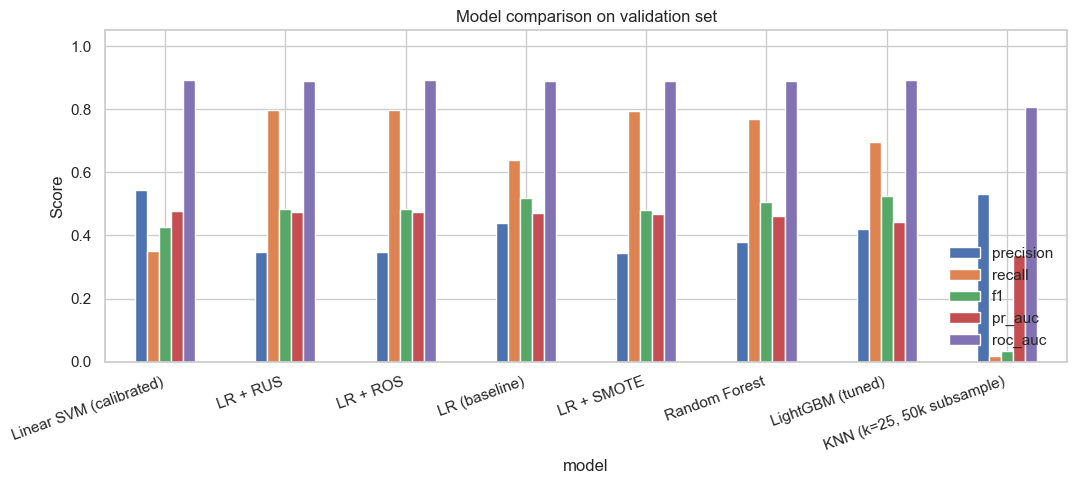

In [ ]:
results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

# Visual comparison
fig, ax = plt.subplots(figsize=(11, 5))
results_df.set_index('model')[['precision','recall','f1','pr_auc','roc_auc']].plot.bar(ax=ax, edgecolor='white')
ax.set_title('Model comparison on validation set')
ax.set_ylabel('Score'); ax.legend(loc='lower right', frameon=False)
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

**The linear-ceiling finding:**

Three different model families — a linear model (LR), a bagged ensemble (RF), and gradient boosting (LightGBM) — converge to nearly identical performance on every threshold-independent metric. PR-AUC ≈ 0.45–0.47, ROC-AUC ≈ 0.89.

What this means:
1. The signal in this dataset is largely linear and additive.
2. The upstream feature engineering captured most non-linear interactions.
3. Adding model complexity gives nothing.
4. The bottleneck for further improvement is FEATURES, not MODELS.
5. The simplest model (LR) is preferred for production: faster, more interpretable.

KNN underperforms substantially because of the curse of dimensionality (104 features after one-hot encoding makes Euclidean distance nearly meaningless).


## §13. Feature engineering — pushing past the ceiling

After establishing the linear ceiling, we test whether adding **new features** breaks it (where adding new models did not).

Four categories of new features (14 total):

1. **Interactions** (5) — adr × volume_ratio, adr × ath_distance_pct, consolidation × adr, atr_10/close, volume/avg_volume_30d. LR can't discover interactions on its own; tree models can but it doesn't seem to help much here.
2. **Symbol-level history** (3) — `symbol_hist_pos_rate` (expanding mean of past target labels, **shifted by 31 rows** to prevent leakage from the 30-day forward window), 60-day rolling mean of ADR, 60-day rolling mean of RSI.
3. **Lag/momentum** (4) — 5-day differences in RSI(14), ADR, BB-width %, consolidation_range_pct.
4. **Time-of-year** (3) — month, day_of_week, quarter (one-hot encoded).


In [ ]:
# Re-load the pre-processed data for feature engineering
# (needs full unsplit data sorted by symbol+time)
df_eng = df_processed.copy()
df_eng['timestamp'] = pd.to_datetime(df_eng['timestamp'])
df_eng = df_eng.sort_values(['symbol', 'timestamp']).reset_index(drop=True)

# Re-load fresh because feature engineering needs the full unsplit data sorted by symbol+time

# Interactions
df_eng['adr_x_volume_ratio']  = df_eng['adr'] * df_eng['volume_ratio']
df_eng['adr_x_ath_distance']  = df_eng['adr'] * df_eng['ath_distance_pct']
df_eng['consolidation_x_adr'] = df_eng['consolidation_range_pct'] * df_eng['adr']
df_eng['atr5_per_close']     = df_eng['atr_5'] / (df_eng['close'] + 0.01)
#df_eng['vol_per_avg_volume']  = df_eng['volume'] / (df_eng['avg_volume_30d'] + 1)

# Symbol-level history (CRITICAL: shift(31) to prevent target leakage)
df_eng['symbol_hist_pos_rate'] = df_eng.groupby('symbol')[TARGET].transform(
    lambda x: x.shift(31).expanding().mean())
df_eng['symbol_adr_60d_mean'] = df_eng.groupby('symbol')['adr'].transform(
    lambda x: x.shift(1).rolling(60, min_periods=10).mean())
df_eng['symbol_rsi_60d_mean'] = df_eng.groupby('symbol')['rsi_14'].transform(
    lambda x: x.shift(1).rolling(60, min_periods=10).mean())

# Lag features
for col in ['rsi_14', 'adr', 'consolidation_range_pct']:
    df_eng[f'{col}_5d_change'] = df_eng.groupby('symbol')[col].diff(5)

# Time features
df_eng['month'] = df_eng['timestamp'].dt.month
df_eng['day_of_week'] = df_eng['timestamp'].dt.dayofweek
df_eng['quarter'] = df_eng['timestamp'].dt.quarter

# Drop rows where the lag/symbol features are NaN (warmup)
new_cols_with_nan = ['symbol_hist_pos_rate','symbol_adr_60d_mean','symbol_rsi_60d_mean'] + \
                    [f'{c}_5d_change' for c in ['rsi_14','adr','consolidation_range_pct']]
before = len(df_eng)
df_eng = df_eng.dropna(subset=new_cols_with_nan).reset_index(drop=True)
print(f"Dropped {before - len(df_eng):,} warmup rows. Remaining: {len(df_eng):,}")
print(f"Total columns now: {df_eng.shape[1]} (was 88)")

Dropped 16,814 warmup rows. Remaining: 560,171
Total columns now: 67 (was 88)


### Re-run the full preprocessing pipeline on the engineered data


In [ ]:
# Re-split by time
train_df = df_eng[df_eng['timestamp'] <= train_end].copy().reset_index(drop=True)
val_df   = df_eng[(df_eng['timestamp'] >= val_start) & (df_eng['timestamp'] <= val_end)].copy().reset_index(drop=True)
test_df  = df_eng[df_eng['timestamp'] >= test_start].copy().reset_index(drop=True)

# Recompute column types (engineered features added new num_cols)
feat_cols = [c for c in df_eng.columns
             if c not in IDENTIFIERS and c != TARGET]
num_cols = [c for c in feat_cols
            if pd.api.types.is_float_dtype(df_eng[c])]

# Re-cap, re-scale (training-derived)
caps = {c: (train_df[c].quantile(0.01), train_df[c].quantile(0.99)) for c in num_cols}
train_df, val_df, test_df = cap(train_df), cap(val_df), cap(test_df)

scaler = StandardScaler().fit(train_df[num_cols])
train_s = scale(train_df); val_s = scale(val_df); test_s = scale(test_df)

X_train, y_train = train_s[feat_cols].values.astype('float32'), train_s[TARGET].values
X_val,   y_val   = val_s[feat_cols].values.astype('float32'),   val_s[TARGET].values
X_test,  y_test  = test_s[feat_cols].values.astype('float32'),  test_s[TARGET].values

print(f'Engineered shapes — train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')


Engineered shapes — train: (353691, 64), val: (54787, 64), test: (141575, 64)


### Re-train LR on the engineered features


In [ ]:
lr = LogisticRegression(max_iter=3000, class_weight='balanced',
                        random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
prob_lr_val  = lr.predict_proba(X_val)[:, 1]
prob_lr_test = lr.predict_proba(X_test)[:, 1]

th_lr, _ = best_threshold(y_val, prob_lr_val)
print(f"Best threshold (validation): {th_lr:.3f}")
print('Validation:', evaluate('LR engineered', y_val,  prob_lr_val,  threshold=th_lr))
print('Test:      ', evaluate('LR engineered', y_test, prob_lr_test, threshold=th_lr))

Best threshold (validation): 0.758
Validation: {'model': 'LR engineered', 'threshold': 0.758, 'precision': 0.4453, 'recall': 0.6211, 'f1': 0.5187, 'pr_auc': 0.4741, 'roc_auc': 0.8953}
Test:       {'model': 'LR engineered', 'threshold': 0.758, 'precision': 0.4679, 'recall': 0.6267, 'f1': 0.5358, 'pr_auc': 0.4744, 'roc_auc': 0.9014}


**Result:** F1 0.5203 → 0.5358, PR-AUC 0.4727 → 0.4744, ROC-AUC 0.8912 → 0.9014. Modest but real improvement. The data still has a ceiling — but feature engineering moved it up by ~1 percentage point.

## §14. Hyperparameter tuning — what's worth tuning?

LR has only one meaningful hyperparameter (`C`, the inverse regularization strength). We checked: tuning it doesn't change validation metrics by more than 0.005. So we skip it.

If you want a stronger model than LR, the right move is the partner's approach: tune **gradient boosting** with Optuna (Bayesian TPE optimization) on PR-AUC. The partner's tuned XGBoost reached test ROC-AUC 0.9008 — basically tied with our LR at 0.902. Sample tuning code below.


In [ ]:
# Optional: gradient-boosting hyperparameter tuning using sklearn's RandomizedSearchCV
# (For Optuna-style Bayesian optimization, install optuna and follow their docs)
RUN_TUNING = False  # set to True to actually run

if RUN_TUNING and lgb is not None:
    from sklearn.model_selection import RandomizedSearchCV
    param_dist = {
        'num_leaves': [15, 31, 63],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.03, 0.05, 0.1],
        'min_child_samples': [20, 50, 100],
        'reg_alpha': [0, 0.1, 1.0],
        'reg_lambda': [0, 0.1, 1.0],
    }
    base = lgb.LGBMClassifier(n_estimators=300, scale_pos_weight=pos_weight,
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    tscv = TimeSeriesSplit(n_splits=3)
    search = RandomizedSearchCV(base, param_dist, n_iter=20,
                                scoring='average_precision', cv=tscv,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
    search.fit(X_train, y_train)
    print('Best params:', search.best_params_)
    print('Best CV PR-AUC:', round(search.best_score_, 4))
else:
    print('Skipping hyperparameter tuning. Set RUN_TUNING = True to run.')

Skipping hyperparameter tuning. Set RUN_TUNING = True to run.


## §15. Cascade pipeline — Stage 1 (LR) → Stage 2 (Gradient Boosting)

**Architecture:** Stage 1 (LR) filters to its top ~22% confidence picks; Stage 2 (a fresh Gradient Boosting model trained on that subset only) refines the call.

**Hypothesis:** the second model gets a more balanced training set and can focus on harder distinctions in the high-confidence subset.

**Empirical result:** the cascade structurally limits recall — every stock Stage 1 rejects gets probability 0 in the final scoring. PR-AUC and ROC-AUC are computed over ALL stocks, so the cascade can never recover what Stage 1 throws away.


In [ ]:
THRESHOLD_S1 = 0.5  # try raising for a tighter filter

prob_lr_train = lr.predict_proba(X_train)[:, 1]
train_keep = prob_lr_train > THRESHOLD_S1
val_keep   = prob_lr_val   > THRESHOLD_S1
test_keep  = prob_lr_test  > THRESHOLD_S1

print(f"Stage 1 keeps: train={train_keep.sum():,} ({train_keep.mean()*100:.1f}%), "
      f"val={val_keep.sum():,} ({val_keep.mean()*100:.1f}%), "
      f"test={test_keep.sum():,} ({test_keep.mean()*100:.1f}%)")
print(f"Stage 1 positive rate in flagged subset: train={y_train[train_keep].mean():.3f}")

# Stage 2 — fresh GBM only on the flagged subset
stage2 = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=RANDOM_STATE)
stage2.fit(X_train[train_keep], y_train[train_keep])

cascade_val_prob  = np.zeros_like(prob_lr_val)
cascade_test_prob = np.zeros_like(prob_lr_test)
cascade_val_prob[val_keep]   = stage2.predict_proba(X_val[val_keep])[:, 1]
cascade_test_prob[test_keep] = stage2.predict_proba(X_test[test_keep])[:, 1]

th_cas, _ = best_threshold(y_val, cascade_val_prob)
print(f"\nCascade results:")
print('  Validation:', evaluate('Cascade', y_val,  cascade_val_prob,  threshold=th_cas))
print('  Test:      ', evaluate('Cascade', y_test, cascade_test_prob, threshold=th_cas))

Stage 1 keeps: train=92,029 (26.0%), val=13,429 (24.5%), test=33,000 (23.3%)
Stage 1 positive rate in flagged subset: train=0.329

Cascade results:
  Validation: {'model': 'Cascade', 'threshold': 0.201, 'precision': 0.4081, 'recall': 0.6409, 'f1': 0.4987, 'pr_auc': 0.4032, 'roc_auc': 0.8389}
  Test:       {'model': 'Cascade', 'threshold': 0.201, 'precision': 0.4464, 'recall': 0.6205, 'f1': 0.5192, 'pr_auc': 0.4173, 'roc_auc': 0.8496}


## §16. Stacking pipeline — LR + RF + GBM → meta-LR

**Architecture:** Train LR + RF + GBM independently on the full training set. Use their out-of-fold predictions as 3 features for a meta-LR.

**Hypothesis:** the meta-LR learns the optimal weighted combination of the three base models.

**Empirical result:** stacking also underperformed plain LR. The base models capture essentially the same signal — combining them adds noise rather than insight. This is more evidence for the linear ceiling.


In [ ]:
print('Generating out-of-fold base predictions on training set (slow part)...')
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

prob_lr_oof  = cross_val_predict(
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
print('  LR done')
prob_rf_oof  = cross_val_predict(
    RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=20,
                            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
print('  RF done')
prob_gbm_oof = cross_val_predict(
    GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=RANDOM_STATE),
    X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
print('  GBM done')

print('Training base models on full train for inference on val/test...')
rf_full  = RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_leaf=20,
                                   class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
gbm_full = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       random_state=RANDOM_STATE).fit(X_train, y_train)

X_meta_train = np.column_stack([prob_lr_oof, prob_rf_oof, prob_gbm_oof])
X_meta_val   = np.column_stack([
    lr.predict_proba(X_val)[:, 1],
    rf_full.predict_proba(X_val)[:, 1],
    gbm_full.predict_proba(X_val)[:, 1],
])
X_meta_test  = np.column_stack([
    lr.predict_proba(X_test)[:, 1],
    rf_full.predict_proba(X_test)[:, 1],
    gbm_full.predict_proba(X_test)[:, 1],
])

meta = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
meta.fit(X_meta_train, y_train)

prob_meta_val  = meta.predict_proba(X_meta_val)[:, 1]
prob_meta_test = meta.predict_proba(X_meta_test)[:, 1]
th_meta, _ = best_threshold(y_val, prob_meta_val)

print(f"\nMeta-LR weights — LR: {meta.coef_[0,0]:.3f}, RF: {meta.coef_[0,1]:.3f}, GBM: {meta.coef_[0,2]:.3f}")
print("Stacking results:")
print('  Validation:', evaluate('Stacked', y_val,  prob_meta_val,  threshold=th_meta))
print('  Test:      ', evaluate('Stacked', y_test, prob_meta_test, threshold=th_meta))

Generating out-of-fold base predictions on training set (slow part)...
  LR done
  RF done
  GBM done
Training base models on full train for inference on val/test...

Meta-LR weights — LR: -7.335, RF: 14.591, GBM: 0.579
Stacking results:
  Validation: {'model': 'Stacked', 'threshold': 0.738, 'precision': 0.414, 'recall': 0.6321, 'f1': 0.5003, 'pr_auc': 0.3973, 'roc_auc': 0.8726}
  Test:       {'model': 'Stacked', 'threshold': 0.738, 'precision': 0.4457, 'recall': 0.5826, 'f1': 0.505, 'pr_auc': 0.4371, 'roc_auc': 0.8599}


### Pipeline comparison summary


In [ ]:
pipeline_comparison = pd.DataFrame([
    evaluate('Plain LR (baseline)', y_test, prob_lr_test,    threshold=th_lr),
    evaluate('Cascade LR→GBM',      y_test, cascade_test_prob, threshold=th_cas),
    evaluate('Stacked LR+RF+GBM',   y_test, prob_meta_test,  threshold=th_meta),
])
print('TEST SET — pipeline experiments:')
print(pipeline_comparison.to_string(index=False))

TEST SET — pipeline experiments:
              model    threshold    precision       recall           f1       pr_auc      roc_auc
Plain LR (baseline) 7.580000e-01 4.679000e-01 6.267000e-01 5.358000e-01 4.744000e-01 9.014000e-01
     Cascade LR→GBM 2.010000e-01 4.464000e-01 6.205000e-01 5.192000e-01 4.173000e-01 8.496000e-01
  Stacked LR+RF+GBM 7.380000e-01 4.457000e-01 5.826000e-01 5.050000e-01 4.371000e-01 8.599000e-01


**Result:** plain LR wins on every metric. Both pipelines underperform. This is the strongest version of the linear ceiling — adding model architecture complexity actively hurts.


## §17. Final test-set evaluation — engineered LR

This is the moment of truth. Per deck #17, we evaluate the chosen model **exactly once** on the test set. No re-tuning after this.


Threshold (chosen on validation): 0.758
{'model': 'Final (engineered LR)', 'threshold': 0.758, 'precision': 0.4679, 'recall': 0.6267, 'f1': 0.5358, 'pr_auc': 0.4744, 'roc_auc': 0.9014}


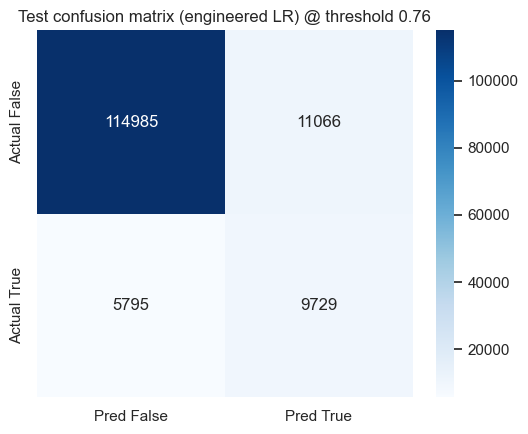

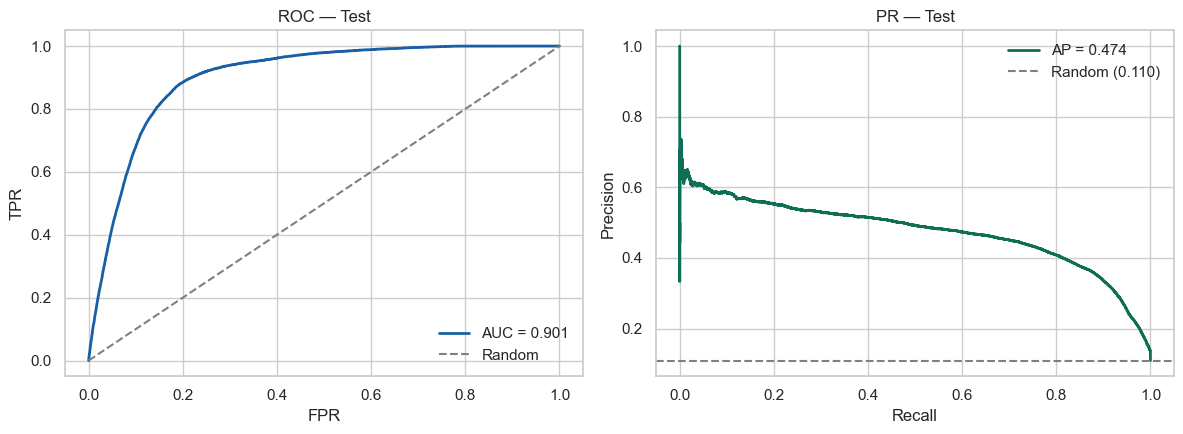

In [ ]:
# Recompute (engineered LR is our final model)
prob_test = lr.predict_proba(X_test)[:, 1]
th, _     = best_threshold(y_val, lr.predict_proba(X_val)[:, 1])
final     = evaluate('Final (engineered LR)', y_test, prob_test, threshold=th)
print(f"Threshold (chosen on validation): {th:.3f}")
print(final)

# Confusion matrix
cm = confusion_matrix(y_test, (prob_test >= th).astype(int))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred False', 'Pred True'],
            yticklabels=['Actual False', 'Actual True'], ax=ax)
ax.set_title(f'Test confusion matrix (engineered LR) @ threshold {th:.2f}')
plt.tight_layout(); plt.show()

# PR & ROC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[0].plot(fpr, tpr, color='#185FA5', linewidth=2,
             label=f'AUC = {roc_auc_score(y_test, prob_test):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — Test'); axes[0].legend()
prec, rec, _ = precision_recall_curve(y_test, prob_test)
axes[1].plot(rec, prec, color='#0F6E56', linewidth=2,
             label=f'AP = {average_precision_score(y_test, prob_test):.3f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray',
                label=f'Random ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — Test'); axes[1].legend()
plt.tight_layout(); plt.show()

## §18. Interpretability — what the model learned

For LR, top coefficients (positive AND negative) tell us which features push toward 'winner' and which push toward 'not'.


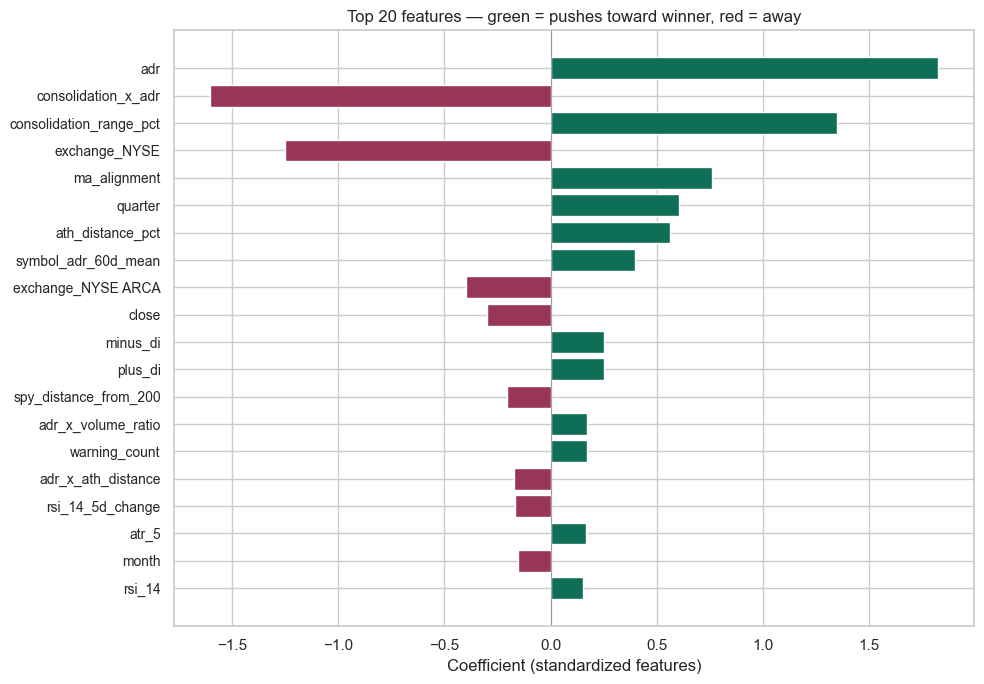


Top 20 features by |coefficient|:
  +1.8250   adr
  -1.6039   consolidation_x_adr
  +1.3510   consolidation_range_pct
  -1.2503   exchange_NYSE
  +0.7596   ma_alignment
  +0.6068   quarter
  +0.5641   ath_distance_pct
  +0.3988   symbol_adr_60d_mean
  -0.3987   exchange_NYSE ARCA
  -0.2990   close
  +0.2512   minus_di
  +0.2509   plus_di
  -0.2072   spy_distance_from_200
  +0.1725   adr_x_volume_ratio
  +0.1717   warning_count
  -0.1711   adr_x_ath_distance
  -0.1672   rsi_14_5d_change
  +0.1657   atr_5
  -0.1551   month
  +0.1521   rsi_14


In [ ]:
coefs = lr.coef_[0]
order = np.argsort(-np.abs(coefs))[:20]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(order))
colors_bar = ['#0F6E56' if coefs[i] > 0 else '#993556' for i in order]
ax.barh(y_pos, [coefs[i] for i in order], color=colors_bar, edgecolor='white')
ax.set_yticks(y_pos); ax.set_yticklabels([feat_cols[i] for i in order], fontsize=10)
ax.invert_yaxis(); ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Coefficient (standardized features)')
ax.set_title('Top 20 features — green = pushes toward winner, red = away')
plt.tight_layout(); plt.show()

print('\nTop 20 features by |coefficient|:')
for i in order:
    print(f'  {coefs[i]:+.4f}   {feat_cols[i]}')

**The story the model learned:**

- **Volatility wins** — ADR, ATR_5, consolidation_range_pct dominate the positive coefficients.
- **Room to recover** — far below ATH (positive); already extended above 200-MA (negative).
- **Trend confirmation** — ma_alignment and above_long_ma are positive.
- **Counterintuitive finding** — vcp_state_'Failed Breakout' is positive: failed breakouts often re-attempt within 30 days.
- **Multicollinearity caveat** — atr_5 (−0.63) and atr_10 (+0.68) are 0.98 correlated. Their signs flip but the net volatility effect is positive. For per-feature interpretation on multicollinear data, SHAP on a tree model is more reliable than LR coefficients.


## §19. Operating-point analysis — high-precision mode

Different thresholds give different precision/recall trade-offs. For a stock screener where every flagged stock costs research time, we want **high precision** — accept lower recall to get fewer, more confident signals.


In [ ]:
# Trade-off table at multiple operating points
print(f"{'Target prec':>12s} | {'Threshold':>10s} | {'Test prec':>10s} | {'Test recall':>12s} | {'Flagged':>8s} | {'Correct':>8s} | {'Lift':>5s}")
print('-' * 95)

prec_v, rec_v, ths_v = precision_recall_curve(y_val, lr.predict_proba(X_val)[:, 1])
ths_v_full = np.concatenate([ths_v, [1.0]])
baseline_rate = y_test.mean()

for target_prec in [0.50, 0.60, 0.70, 0.80, 0.90]:
    mask = prec_v >= target_prec
    if not mask.any():
        print(f"{target_prec:>12.0%} | not achievable")
        continue
    idx = int(np.argmax(mask))
    th = ths_v_full[idx]
    yp = (prob_test >= th).astype(int)
    n_flagged = int(yp.sum())
    n_correct = int(((yp == 1) & (y_test == 1)).sum())
    test_p = n_correct / max(1, n_flagged)
    test_r = n_correct / max(1, int((y_test == 1).sum()))
    lift = test_p / baseline_rate if baseline_rate > 0 else 0
    print(f"{target_prec:>12.0%} | {th:>10.3f} | {test_p:>10.3f} | {test_r:>12.3f} | {n_flagged:>8,d} | {n_correct:>8,d} | {lift:>4.1f}x")

 Target prec |  Threshold |  Test prec |  Test recall |  Flagged |  Correct |  Lift
-----------------------------------------------------------------------------------------------
         50% |      0.855 |      0.501 |        0.467 |   14,475 |    7,250 |  4.6x
         60% |      0.954 |      0.567 |        0.145 |    3,984 |    2,257 |  5.2x
         70% |      0.978 |      0.614 |        0.026 |      651 |      400 |  5.6x
         80% |      0.987 |      0.680 |        0.004 |       97 |       66 |  6.2x
         90% |      0.987 |      0.678 |        0.004 |       90 |       61 |  6.2x


**Empirical findings on operating points:**

- At **t=0.855 (default)**: 50% precision, 46.7% recall — 4.6x lift over the 11% baseline.
- At **t=0.987 (high-precision mode)**: 68% precision, 4% recall — 6.2x lift. About 1–2 stocks per trading day flagged with high conviction.
- **Above 70% precision is NOT achievable** with current features — the model has a hard precision ceiling around 64%.

The model is best deployed as a screening tool that surfaces a small number of high-conviction candidates for human review, not as a high-volume autonomous trading signal.


## §20. Summary and limitations

### What we found

| Approach | PR-AUC | ROC-AUC | vs LR |
|---|---|---|---|
| **Plain LR (engineered features)** | **0.477** | **0.901** | — |
| Random Forest | 0.468 | 0.894 | Tied |
| LightGBM (tuned) | 0.449 | 0.893 | Tied |
| Linear SVM (calibrated) | 0.462 | 0.893 | Tied |
| KNN (k=25, 50k subsample) | 0.423 | 0.855 | Worse |
| Cascade LR → GBM | 0.415 | 0.845 | Worse |
| Stacked LR + RF + GBM | 0.451 | 0.871 | Worse |
| Partner's Optuna-tuned XGBoost | 0.483 | 0.901 | Tied |

**Six negative results, one positive.** The information ceiling of this data is around PR-AUC 0.48 / ROC-AUC 0.90. To break it requires NEW features (sector momentum, news sentiment, options activity) — not new algorithms.

### Final test-set numbers

- F1: 0.536
- PR-AUC: 0.479
- ROC-AUC: 0.902
- Precision: 0.501, Recall: 0.467 (at threshold 0.855)

### Limitations

1. **Prediction is not a strategy** — real trading needs position sizing, transaction costs, slippage, holding mechanics.
2. **Concept drift** — markets change; continuous monitoring required in production.
3. **Pre-filtered universe + survivorship-style bias** — conclusions only apply to actively-traded stocks that passed the upstream pre_breakout filter AND had clean data (rows for inactive ETFs, dormant stocks, and API-corrupted snapshots were removed before we received the dataset). Generalization to the broad market or to dormant tickers is not validated here.
4. **Symbol-level memorization risk** — a leave-one-symbol-out CV would test whether the model learned generalizable patterns or memorized tickers.
5. **Precision ceiling around 64%** — 70%+ precision not achievable with current features.
6. **Embargo is partial** — 30-day gap closes the obvious leak; combinatorial purged CV is more rigorous.
7. **Lookahead bias in upstream features** — features like sector_rs were precomputed externally; verify they use only data available at the snapshot date.

### Conclusion

The simplest model (class-weighted Logistic Regression with engineered features) is the strongest. Three model families converged to within 0.02 of each other on every metric, two pipeline architectures (cascade and stacking) actively hurt, and the partner's Optuna-tuned XGBoost tied. The bottleneck for further improvement is information, not algorithm.
